This notebook analyze exr6>+ and exr6>kir2.1 flies behavior in an arena with no visual cue.

In [ ]:
import sleap
import sleap_io as sio
import re
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt

from pathlib import Path
import warnings



In [4]:
print("Python executable:")
print(sys.executable)

print("\nSLEAP version:")
print(sleap.__version__)

Python executable:
c:\Users\FISHER-LAB\AppData\Local\Programs\Python\Python313\python.exe

SLEAP version:
1.6.3


In [5]:
import shutil

print(shutil.which("sleap-track"))

C:\Users\FISHER-LAB\AppData\Local\Programs\Python\Python313\Scripts\sleap-track.EXE


In [6]:
import subprocess

sleap_track_path = (
    r"C:\Users\FISHER-LAB\AppData\Local\Programs"
    r"\Python\Python313\Scripts\sleap-track.EXE"
)

result = subprocess.run(
    [sleap_track_path, "--help"],
    capture_output=True,
    text=True,
)

print(result.stdout)
print(result.stderr)

Usage: sleap-track.EXE [OPTIONS] DATA_PATH

  Track instances in video data using trained SLEAP models.

Options:
  -m, --model TEXT                Path to trained model directory (with
                                  training_config json/yaml). Multiple models
                                  can be specified, each preceded by --model.
  --frames TEXT                   List of frames to predict when running on a
                                  video. Can be specified as a comma separated
                                  list (e.g. 1,2,3) or a range separated by
                                  hyphen (e.g., 1-3, for 1,2,3). If not
                                  provided, defaults to predicting on the
                                  entire video.
  --only-labeled-frames           Only run inference on user labeled frames
                                  when running on labels dataset. This is
                                  useful for generating predictions to compare
  

Level 0: load .slp → clean dataframe\
Level 1: Geometry & Quality Control\
Level 2: behavioral states\
Level 3–4: walking/stopping bouts\
Level 5: reorientation after stops\
Level 6–8: turns, spatial behavior, exploration\
Level 9: directional bias\
Level 10: optogenetic epoch analysis

# level 0

In [ ]:
df = 0 # refresh

In [10]:
higherres_root = Path(r"C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\higherres")


def load_condition_slp_projects(condition_folder):
    """
    Load one SLEAP v002 project from each individual-fly folder.

    Expected filename pattern:
        fly<number>_<1 or 2>.v002.slp

    Dictionary key:
        fly<number>

    Example:
        fly19_1.v002.slp -> key "fly19_1"

    Raises an error if:
    - a fly folder has no matching v002.slp file,
    - a fly folder has more than one matching v002.slp file,
    - two files would produce the same fly key.
    """

    condition_path = higherres_root / condition_folder

    if not condition_path.exists():
        raise FileNotFoundError(
            f"Condition folder does not exist:\n{condition_path}"
        )

    loaded_flies = {}

    # Look through all immediate subfolders, one folder per fly.
    fly_folders = sorted(
        path for path in condition_path.iterdir()
        if path.is_dir()
    )

    for fly_folder in fly_folders:

        # Only accept filenames ending exactly in .v002.slp.
        matching_files = sorted(fly_folder.glob("fly*_*.v002.slp"))

        if len(matching_files) == 0:
            raise FileNotFoundError(
                f"No file ending in '.v002.slp' was found in:\n"
                f"{fly_folder}"
            )

        if len(matching_files) > 1:
            raise RuntimeError(
                f"More than one '.v002.slp' file was found in:\n"
                f"{fly_folder}\n"
                f"Files: {matching_files}"
            )

        slp_path = matching_files[0]

        # Example stem:
        # fly19_1.v002
        match = re.fullmatch(
            r"(fly\d+_[12])\.v002",
            slp_path.stem
        )

        if match is None:
            raise ValueError(
                f"Unexpected filename format:\n{slp_path.name}"
            )

        # Example: fly19_1.v002 -> fly19_1
        fly_name = match.group(1)

        if fly_name in loaded_flies:
            raise ValueError(
                f"Duplicate fly key '{fly_name}'.\n"
                f"Removing _1/_2 would cause one project to overwrite another."
            )

        loaded_flies[fly_name] = sio.load_slp(slp_path)

        print(
            f"Loaded {condition_folder} / {fly_name}: "
            f"{slp_path.name}"
        )

    return loaded_flies

In [124]:
control = load_condition_slp_projects("exr6-+")
exr6_kir = load_condition_slp_projects("exr6-kir")

Loaded exr6-+ / fly19_1: fly19_1.v002.slp


In [125]:
print("\nControl flies:")
print(list(control.keys()))

print("\nExr6-Kir flies:")
print(list(exr6_kir.keys()))


Control flies:
['fly19_1']

Exr6-Kir flies:
[]


# level 0 new
run inference in vs code

In [3]:
base_folder = Path(
    r"C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue"
)

video_folders = [
    base_folder / "exr6-+",
    base_folder / "exr6-kir",
]

filename_pattern = re.compile(
    r"^sc_fly(\d+)_1_.*\.avi$",
    re.IGNORECASE,
)

selected_videos = []

for folder in video_folders:
    for video_path in folder.glob("*.avi"):
        match = filename_pattern.match(video_path.name)

        if match is None:
            continue

        fly_number = int(match.group(1))

        if fly_number > 18:
            selected_videos.append(video_path)

selected_videos = sorted(selected_videos)

for video_path in selected_videos:
    print(video_path)

C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly19_1_2026-07-01-155516-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly21_1_2026-07-01-172407-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly23_1_2026-07-02-093606-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly25_1_2026-07-07-095354-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly27_1_2026-07-10-105004-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly29_1_2026-07-10-115616-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly31_1_2026-07-10-140502-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly33_1_2026-07-10-151033-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-kir\sc_fly20_1_2026-07-01-164211-0000.avi
C:\Users\FISHER-LAB\Documents\camera GS3-U3-

In [30]:
sleap_track = (
    r"C:\Users\FISHER-LAB\AppData\Local\Programs\Python"
    r"\Python313\Scripts\sleap-track.EXE"
)

centroid_model = (
    r"C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\fly19_model\models"
    r"\260708_165803.centroid.n=25"
)

centered_instance_model = (
    r"C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\fly19_model\models"
    r"\260708_180447.centered_instance.n=25"
)

output_folder = Path(
    r"C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tracking_using_fly19_model"
)
output_folder.mkdir(exist_ok=True)

In [31]:
n_videos = len(selected_videos)

for i, video_path in enumerate(selected_videos, start=1):

    output_path = output_folder / f"{video_path.stem}.predictions.slp"

    print("=" * 70)
    print(f"[{i}/{n_videos}] Running inference")
    print(video_path.name)
    print()

    command = [
        sleap_track,
        str(video_path),

        # models
        "--model", centroid_model,
        "--model", centered_instance_model,

        # tracker settings
        "--tracking.tracker", "simple",
        "--tracking.similarity", "centroid",
        "--tracking.match", "hungarian",
        "--tracking.robust", "1",

        # one fly only
        "--tracking.max_tracking", "1",
        "--tracking.max_tracks", "1",

        # use GPU
        "--first-gpu",

        # output
        "--output", str(output_path),
    ]

    subprocess.run(command, check=True)

    print(f"Finished: {output_path.name}")

print("\n" + "=" * 70)
print("All videos have finished!")

[1/16] Running inference
sc_fly19_1_2026-07-01-155516-0000.avi

Finished: sc_fly19_1_2026-07-01-155516-0000.predictions.slp
[2/16] Running inference
sc_fly21_1_2026-07-01-172407-0000.avi

Finished: sc_fly21_1_2026-07-01-172407-0000.predictions.slp
[3/16] Running inference
sc_fly23_1_2026-07-02-093606-0000.avi

Finished: sc_fly23_1_2026-07-02-093606-0000.predictions.slp
[4/16] Running inference
sc_fly25_1_2026-07-07-095354-0000.avi

Finished: sc_fly25_1_2026-07-07-095354-0000.predictions.slp
[5/16] Running inference
sc_fly27_1_2026-07-10-105004-0000.avi

Finished: sc_fly27_1_2026-07-10-105004-0000.predictions.slp
[6/16] Running inference
sc_fly29_1_2026-07-10-115616-0000.avi

Finished: sc_fly29_1_2026-07-10-115616-0000.predictions.slp
[7/16] Running inference
sc_fly31_1_2026-07-10-140502-0000.avi

Finished: sc_fly31_1_2026-07-10-140502-0000.predictions.slp
[8/16] Running inference
sc_fly33_1_2026-07-10-151033-0000.avi

Finished: sc_fly33_1_2026-07-10-151033-0000.predictions.slp
[9/16] R

In [32]:
# load all tracked SLEAP files
tracked_slp_folder = Path(
    r"C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tracking_using_fly19_model"
)

tracked_slp_paths = sorted(
    tracked_slp_folder.glob("*.predictions.slp")
)

print(f"Found {len(tracked_slp_paths)} tracked SLP files:\n")

for slp_path in tracked_slp_paths:
    print(slp_path.name)

Found 16 tracked SLP files:

sc_fly19_1_2026-07-01-155516-0000.predictions.slp
sc_fly20_1_2026-07-01-164211-0000.predictions.slp
sc_fly21_1_2026-07-01-172407-0000.predictions.slp
sc_fly22_1_2026-07-01-175344-0000.predictions.slp
sc_fly23_1_2026-07-02-093606-0000.predictions.slp
sc_fly24_1_2026-07-02-102056-0000.predictions.slp
sc_fly25_1_2026-07-07-095354-0000.predictions.slp
sc_fly26_1_2026-07-07-102306-0000.predictions.slp
sc_fly27_1_2026-07-10-105004-0000.predictions.slp
sc_fly28_1_2026-07-10-111709-0000.predictions.slp
sc_fly29_1_2026-07-10-115616-0000.predictions.slp
sc_fly30_1_2026-07-10-122847-0000.predictions.slp
sc_fly31_1_2026-07-10-140502-0000.predictions.slp
sc_fly32_1_2026-07-10-143559-0000.predictions.slp
sc_fly33_1_2026-07-10-151033-0000.predictions.slp
sc_fly34_1_2026-07-10-154034-0000.predictions.slp


In [33]:
# Load every tracked SLP and collect basic information

all_results = {}
video_summary_rows = []

for slp_path in tracked_slp_paths:

    # Remove ".predictions.slp" to get a clean fly/video name.
    fly_name = slp_path.name.removesuffix(".predictions.slp")

    print(f"Loading: {fly_name}")

    labels = sio.load_slp(slp_path)

    video = labels.videos[0]
    skeleton = labels.skeletons[0]

    video_n_frames = video.shape[0]
    n_labeled_frames = len(labels)

    # Save one summary row for this fly.
    video_summary_rows.append({
        "fly_name": fly_name,
        "slp_path": str(slp_path),
        "video_n_frames": video_n_frames,
        "frames_with_labels_or_predictions": n_labeled_frames,
    })

    # Start the results dictionary for this fly.
    all_results[fly_name] = {
        "slp_path": slp_path,
        "video_n_frames": video_n_frames,
        "frames_with_labels_or_predictions": n_labeled_frames,
        "skeleton_node_names": [node.name for node in skeleton.nodes],
    }


# One row per fly.
video_summary_df = pd.DataFrame(video_summary_rows)
video_summary_df["prediction_frame_fraction"] = (
    video_summary_df["frames_with_labels_or_predictions"]
    / video_summary_df["video_n_frames"])
video_summary_df

Loading: sc_fly19_1_2026-07-01-155516-0000
Loading: sc_fly20_1_2026-07-01-164211-0000
Loading: sc_fly21_1_2026-07-01-172407-0000
Loading: sc_fly22_1_2026-07-01-175344-0000
Loading: sc_fly23_1_2026-07-02-093606-0000
Loading: sc_fly24_1_2026-07-02-102056-0000
Loading: sc_fly25_1_2026-07-07-095354-0000
Loading: sc_fly26_1_2026-07-07-102306-0000
Loading: sc_fly27_1_2026-07-10-105004-0000
Loading: sc_fly28_1_2026-07-10-111709-0000
Loading: sc_fly29_1_2026-07-10-115616-0000
Loading: sc_fly30_1_2026-07-10-122847-0000
Loading: sc_fly31_1_2026-07-10-140502-0000
Loading: sc_fly32_1_2026-07-10-143559-0000
Loading: sc_fly33_1_2026-07-10-151033-0000
Loading: sc_fly34_1_2026-07-10-154034-0000


,fly_name,slp_path,video_n_frames,frames_with_labels_or_predictions,prediction_frame_fraction
0,sc_fly19_1_2026-07-01-155516-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8997,0.999667
1,sc_fly20_1_2026-07-01-164211-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8721,0.969000
2,sc_fly21_1_2026-07-01-172407-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8892,0.988000
3,sc_fly22_1_2026-07-01-175344-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8830,0.981111
4,sc_fly23_1_2026-07-02-093606-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8924,0.991556
5,sc_fly24_1_2026-07-02-102056-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8848,0.983111
6,sc_fly25_1_2026-07-07-095354-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,13500,13473,0.998000
7,sc_fly26_1_2026-07-07-102306-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8844,0.982667
8,sc_fly27_1_2026-07-10-105004-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8988,0.998667
9,sc_fly28_1_2026-07-10-111709-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8880,0.986667


In [34]:
# convert every SLEAP tracking file into a dataframe
for i, slp_path in enumerate(tracked_slp_paths, start=1):

    fly_name = slp_path.name.removesuffix(".predictions.slp")

    print(
        f"[{i}/{len(tracked_slp_paths)}] "
        f"Creating Level 0 dataframe for {fly_name}"
    )

    labels = sio.load_slp(slp_path)

    video = labels.videos[0]
    video_n_frames = video.shape[0]

    # Start with one empty row for every frame in the original video.
    # This preserves the true timing even if SLEAP has no prediction
    # for some frames.
    df = pd.DataFrame({
        "frame_idx": np.arange(video_n_frames, dtype=int),
        "instance_score": np.nan,
        "tracking_score": np.nan,
        "head_x": np.nan,
        "head_y": np.nan,
        "head_score": np.nan,
        "tail_x": np.nan,
        "tail_y": np.nan,
        "tail_score": np.nan,
    })

    # Use frame_idx as the temporary index so each prediction can be
    # inserted into its correct original video frame.
    df = df.set_index("frame_idx")

    for labeled_frame in labels:

        frame_idx = labeled_frame.frame_idx

        # Leave this frame as NaN if no animal instance was predicted.
        if len(labeled_frame.instances) == 0:
            continue

        # There is one fly, so take the first predicted instance.
        inst = labeled_frame.instances[0]

        df.loc[frame_idx, "instance_score"] = inst.score
        df.loc[frame_idx, "tracking_score"] = inst.tracking_score

        # Extract coordinates and confidence score for each skeleton node.
        for point in inst.points:

            point_name = str(point[4])
            x, y = point[0]
            point_score = point[1]

            # Ignore unexpected node names.
            if point_name not in {"head", "tail"}:
                continue

            df.loc[frame_idx, f"{point_name}_x"] = x
            df.loc[frame_idx, f"{point_name}_y"] = y
            df.loc[frame_idx, f"{point_name}_score"] = point_score

    # Restore frame_idx as a regular column.
    df = df.reset_index()

    # Store this fly's dataframe.
    all_results[fly_name]["level0_df"] = df

print("\nFinished creating all Level 0 dataframes.")

[1/16] Creating Level 0 dataframe for sc_fly19_1_2026-07-01-155516-0000
[2/16] Creating Level 0 dataframe for sc_fly20_1_2026-07-01-164211-0000
[3/16] Creating Level 0 dataframe for sc_fly21_1_2026-07-01-172407-0000
[4/16] Creating Level 0 dataframe for sc_fly22_1_2026-07-01-175344-0000
[5/16] Creating Level 0 dataframe for sc_fly23_1_2026-07-02-093606-0000
[6/16] Creating Level 0 dataframe for sc_fly24_1_2026-07-02-102056-0000
[7/16] Creating Level 0 dataframe for sc_fly25_1_2026-07-07-095354-0000
[8/16] Creating Level 0 dataframe for sc_fly26_1_2026-07-07-102306-0000
[9/16] Creating Level 0 dataframe for sc_fly27_1_2026-07-10-105004-0000
[10/16] Creating Level 0 dataframe for sc_fly28_1_2026-07-10-111709-0000
[11/16] Creating Level 0 dataframe for sc_fly29_1_2026-07-10-115616-0000
[12/16] Creating Level 0 dataframe for sc_fly30_1_2026-07-10-122847-0000
[13/16] Creating Level 0 dataframe for sc_fly31_1_2026-07-10-140502-0000
[14/16] Creating Level 0 dataframe for sc_fly32_1_2026-07-10

In [35]:
valid_prediction_rows = []

for fly_name, result in all_results.items():

    df = result["level0_df"]

    has_complete_prediction = df[
        ["head_x", "head_y", "tail_x", "tail_y"]
    ].notna().all(axis=1)

    n_complete_predictions = int(has_complete_prediction.sum())

    valid_prediction_rows.append({
        "fly_name": fly_name,
        "frames_with_complete_prediction": n_complete_predictions,
        "complete_prediction_fraction": (
            n_complete_predictions / len(df)
        ),
    })

prediction_summary_df = pd.DataFrame(valid_prediction_rows)

video_summary_df = video_summary_df.merge(
    prediction_summary_df,
    on="fly_name",
    how="left",
)

video_summary_df

,fly_name,slp_path,video_n_frames,frames_with_labels_or_predictions,prediction_frame_fraction,frames_with_complete_prediction,complete_prediction_fraction
0,sc_fly19_1_2026-07-01-155516-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8997,0.999667,8992,0.999111
1,sc_fly20_1_2026-07-01-164211-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8721,0.969000,8615,0.957222
2,sc_fly21_1_2026-07-01-172407-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8892,0.988000,8750,0.972222
3,sc_fly22_1_2026-07-01-175344-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8830,0.981111,8687,0.965222
4,sc_fly23_1_2026-07-02-093606-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8924,0.991556,8819,0.979889
5,sc_fly24_1_2026-07-02-102056-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8848,0.983111,8817,0.979667
6,sc_fly25_1_2026-07-07-095354-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,13500,13473,0.998000,13445,0.995926
7,sc_fly26_1_2026-07-07-102306-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8844,0.982667,8794,0.977111
8,sc_fly27_1_2026-07-10-105004-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8988,0.998667,8982,0.998000
9,sc_fly28_1_2026-07-10-111709-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8880,0.986667,8841,0.982333


In [36]:
# interpolate short gaps in tracking
def interpolate_short_tracking_gaps(
    df,
    *,
    max_gap_frames=3,
    coordinate_columns=(
        "head_x",
        "head_y",
        "tail_x",
        "tail_y",
    ),
):
    """
    Fill short gaps in tracked coordinates using linear interpolation.

    Rules
    -----
    - Gaps of 1 to max_gap_frames consecutive missing frames are filled.
    - Interpolation uses the nearest valid frame before and after the gap.
    - Gaps longer than max_gap_frames are left as NaN and trigger a warning.
    - Gaps at the beginning or end of the video are not filled because they
      do not have valid tracking on both sides.
    - Confidence scores are not interpolated because they are model outputs,
      not physical coordinates.

    New columns
    -----------
    was_missing_originally:
        True if the frame originally lacked complete head/tail coordinates.

    was_interpolated:
        True if the coordinates were filled by interpolation.

    interpolation_gap_length:
        Number of consecutive missing frames in the original gap.
    """

    result = df.copy()

    required_columns = ["frame_idx", *coordinate_columns]

    missing_columns = [
        col
        for col in required_columns
        if col not in result.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing required dataframe columns: {missing_columns}"
        )

    # A frame is considered missing if any required coordinate is absent.
    missing_originally = (
        result[list(coordinate_columns)]
        .isna()
        .any(axis=1)
    )

    result["was_missing_originally"] = missing_originally
    result["was_interpolated"] = False
    result["interpolation_gap_length"] = 0

    # Give each consecutive run of missing/non-missing frames its own ID.
    run_id = (
        missing_originally
        .ne(missing_originally.shift())
        .cumsum()
    )

    for _, run in result.groupby(run_id, sort=True):

        run_indices = run.index

        # Ignore runs that contain valid coordinates.
        if not missing_originally.loc[run_indices[0]]:
            continue

        gap_length = len(run_indices)

        result.loc[
            run_indices,
            "interpolation_gap_length",
        ] = gap_length

        first_idx = run_indices[0]
        last_idx = run_indices[-1]

        previous_idx = first_idx - 1
        next_idx = last_idx + 1

        has_previous_frame = previous_idx in result.index
        has_next_frame = next_idx in result.index

        # Cannot interpolate a gap at the beginning or end of the video.
        if not has_previous_frame or not has_next_frame:
            warnings.warn(
                f"Frames "
                f"{result.loc[first_idx, 'frame_idx']}–"
                f"{result.loc[last_idx, 'frame_idx']} are missing at a "
                f"video boundary and were not interpolated."
            )
            continue

        # Leave long gaps missing.
        if gap_length > max_gap_frames:
            warnings.warn(
                f"Frames "
                f"{result.loc[first_idx, 'frame_idx']}–"
                f"{result.loc[last_idx, 'frame_idx']} form a gap of "
                f"{gap_length} consecutive frames. "
                f"The gap was not interpolated."
            )
            continue

        # Make sure the bounding frames contain valid coordinates.
        bounding_values = result.loc[
            [previous_idx, next_idx],
            list(coordinate_columns),
        ]

        if bounding_values.isna().any().any():
            warnings.warn(
                f"Gap at frames "
                f"{result.loc[first_idx, 'frame_idx']}–"
                f"{result.loc[last_idx, 'frame_idx']} does not have valid "
                f"tracking on both sides and was not interpolated."
            )
            continue

        # Linear interpolation.
        for position_in_gap, row_idx in enumerate(
            run_indices,
            start=1,
        ):
            fraction = position_in_gap / (gap_length + 1)

            for col in coordinate_columns:
                previous_value = result.loc[previous_idx, col]
                next_value = result.loc[next_idx, col]

                result.loc[row_idx, col] = (
                    previous_value
                    + fraction * (next_value - previous_value)
                )

        result.loc[run_indices, "was_interpolated"] = True

    return result

In [37]:
#  apply the interpolation

max_gap_frames = 3

for i, (fly_name, result) in enumerate(
    all_results.items(),
    start=1,
):
    print(
        f"[{i}/{len(all_results)}] "
        f"Interpolating short tracking gaps for {fly_name}"
    )

    level0_df = result["level0_df"]

    level0_interpolated_df = interpolate_short_tracking_gaps(
        level0_df,
        max_gap_frames=max_gap_frames,
    )

    all_results[fly_name][
        "level0_interpolated_df"
    ] = level0_interpolated_df

print("\nFinished interpolating all flies.")

[1/16] Interpolating short tracking gaps for sc_fly19_1_2026-07-01-155516-0000
[2/16] Interpolating short tracking gaps for sc_fly20_1_2026-07-01-164211-0000
[3/16] Interpolating short tracking gaps for sc_fly21_1_2026-07-01-172407-0000
[4/16] Interpolating short tracking gaps for sc_fly22_1_2026-07-01-175344-0000
[5/16] Interpolating short tracking gaps for sc_fly23_1_2026-07-02-093606-0000
[6/16] Interpolating short tracking gaps for sc_fly24_1_2026-07-02-102056-0000
[7/16] Interpolating short tracking gaps for sc_fly25_1_2026-07-07-095354-0000
[8/16] Interpolating short tracking gaps for sc_fly26_1_2026-07-07-102306-0000
[9/16] Interpolating short tracking gaps for sc_fly27_1_2026-07-10-105004-0000
[10/16] Interpolating short tracking gaps for sc_fly28_1_2026-07-10-111709-0000


C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 1–34 form a gap of 34 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 1853–1877 form a gap of 25 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 1883–1902 form a gap of 20 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 2386–2423 form a gap of 38 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 2891–2911 form a gap of 21 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707

[11/16] Interpolating short tracking gaps for sc_fly29_1_2026-07-10-115616-0000
[12/16] Interpolating short tracking gaps for sc_fly30_1_2026-07-10-122847-0000
[13/16] Interpolating short tracking gaps for sc_fly31_1_2026-07-10-140502-0000
[14/16] Interpolating short tracking gaps for sc_fly32_1_2026-07-10-143559-0000
[15/16] Interpolating short tracking gaps for sc_fly33_1_2026-07-10-151033-0000
[16/16] Interpolating short tracking gaps for sc_fly34_1_2026-07-10-154034-0000


C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 50–66 form a gap of 17 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 75–80 form a gap of 6 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 344–350 form a gap of 7 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 393–426 form a gap of 34 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 6–39 form a gap of 34 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserW


Finished interpolating all flies.


C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 1560–1563 form a gap of 4 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 1566–1569 form a gap of 4 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 2451–2466 form a gap of 16 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 2658–2681 form a gap of 24 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353707.py:107: UserWarning: Frames 2698–2711 form a gap of 14 consecutive frames. The gap was not interpolated.
  warnings.warn(
C:\Users\FISHER-LAB\AppData\Local\Temp\ipykernel_15060\2627353

In [38]:
all_results[fly_name]["level0_df"]

,frame_idx,instance_score,tracking_score,head_x,head_y,head_score,tail_x,tail_y,tail_score
0,0,0.990687,1.000000,744.292725,380.199097,0.934034,751.730774,364.501740,0.609170
1,1,0.997533,0.995366,744.336426,380.172180,0.931627,751.777405,364.476929,0.611563
2,2,0.987334,0.996575,744.293213,380.191345,0.930941,751.735229,364.531799,0.602993
3,3,0.994956,0.982818,744.387695,380.147614,0.924057,751.851440,364.501770,0.583410
4,4,1.003730,0.959873,744.443420,380.144928,0.929779,751.943115,364.525330,0.605238
...,...,...,...,...,...,...,...,...,...
8995,8995,0.949268,0.897308,356.848450,268.114288,1.006374,340.662476,280.553223,0.915703
8996,8996,0.944672,0.943917,356.797119,268.179077,1.009127,340.648346,280.514069,0.919791
8997,8997,0.950243,0.963921,356.787476,268.163177,1.009557,340.619537,280.386963,0.921724
8998,8998,0.949830,0.972509,356.790955,268.219055,1.010167,340.626129,280.378571,0.929167


In [39]:
all_results[fly_name]["level0_interpolated_df"]

,frame_idx,instance_score,tracking_score,head_x,head_y,head_score,tail_x,tail_y,tail_score,was_missing_originally,was_interpolated,interpolation_gap_length
0,0,0.990687,1.000000,744.292725,380.199097,0.934034,751.730774,364.501740,0.609170,False,False,0
1,1,0.997533,0.995366,744.336426,380.172180,0.931627,751.777405,364.476929,0.611563,False,False,0
2,2,0.987334,0.996575,744.293213,380.191345,0.930941,751.735229,364.531799,0.602993,False,False,0
3,3,0.994956,0.982818,744.387695,380.147614,0.924057,751.851440,364.501770,0.583410,False,False,0
4,4,1.003730,0.959873,744.443420,380.144928,0.929779,751.943115,364.525330,0.605238,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8995,8995,0.949268,0.897308,356.848450,268.114288,1.006374,340.662476,280.553223,0.915703,False,False,0
8996,8996,0.944672,0.943917,356.797119,268.179077,1.009127,340.648346,280.514069,0.919791,False,False,0
8997,8997,0.950243,0.963921,356.787476,268.163177,1.009557,340.619537,280.386963,0.921724,False,False,0
8998,8998,0.949830,0.972509,356.790955,268.219055,1.010167,340.626129,280.378571,0.929167,False,False,0


In [40]:
# Summarize interpolation across all flies

interpolation_summary_rows = []

for fly_name, result in all_results.items():

    df_interpolated = result["level0_interpolated_df"]

    n_originally_missing = int(
        df_interpolated["was_missing_originally"].sum()
    )

    n_interpolated = int(
        df_interpolated["was_interpolated"].sum()
    )

    n_remaining_missing = int(
        df_interpolated[
            ["head_x", "head_y", "tail_x", "tail_y"]
        ]
        .isna()
        .any(axis=1)
        .sum()
    )

    interpolation_summary_rows.append({
        "fly_name": fly_name,
        "frames_missing_originally": n_originally_missing,
        "frames_interpolated": n_interpolated,
        "frames_still_missing": n_remaining_missing,
        "interpolated_fraction": (
            n_interpolated / len(df_interpolated)
        ),
    })

interpolation_summary_df = pd.DataFrame(
    interpolation_summary_rows
)

interpolation_summary_df

,fly_name,frames_missing_originally,frames_interpolated,frames_still_missing,interpolated_fraction
0,sc_fly19_1_2026-07-01-155516-0000,8,8,0,0.000889
1,sc_fly20_1_2026-07-01-164211-0000,385,15,370,0.001667
2,sc_fly21_1_2026-07-01-172407-0000,250,8,242,0.000889
3,sc_fly22_1_2026-07-01-175344-0000,313,23,290,0.002556
4,sc_fly23_1_2026-07-02-093606-0000,181,9,172,0.001000
5,sc_fly24_1_2026-07-02-102056-0000,183,11,172,0.001222
6,sc_fly25_1_2026-07-07-095354-0000,55,4,51,0.000296
7,sc_fly26_1_2026-07-07-102306-0000,206,24,182,0.002667
8,sc_fly27_1_2026-07-10-105004-0000,18,0,18,0.000000
9,sc_fly28_1_2026-07-10-111709-0000,159,20,139,0.002222


In [41]:
video_summary_df = video_summary_df.merge(
    interpolation_summary_df,
    on="fly_name",
    how="left",
    validate="one_to_one",
)

video_summary_df

,fly_name,slp_path,video_n_frames,frames_with_labels_or_predictions,prediction_frame_fraction,frames_with_complete_prediction,complete_prediction_fraction,frames_missing_originally,frames_interpolated,frames_still_missing,interpolated_fraction
0,sc_fly19_1_2026-07-01-155516-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8997,0.999667,8992,0.999111,8,8,0,0.000889
1,sc_fly20_1_2026-07-01-164211-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8721,0.969000,8615,0.957222,385,15,370,0.001667
2,sc_fly21_1_2026-07-01-172407-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8892,0.988000,8750,0.972222,250,8,242,0.000889
3,sc_fly22_1_2026-07-01-175344-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8830,0.981111,8687,0.965222,313,23,290,0.002556
4,sc_fly23_1_2026-07-02-093606-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8924,0.991556,8819,0.979889,181,9,172,0.001000
5,sc_fly24_1_2026-07-02-102056-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8848,0.983111,8817,0.979667,183,11,172,0.001222
6,sc_fly25_1_2026-07-07-095354-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,13500,13473,0.998000,13445,0.995926,55,4,51,0.000296
7,sc_fly26_1_2026-07-07-102306-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8844,0.982667,8794,0.977111,206,24,182,0.002667
8,sc_fly27_1_2026-07-10-105004-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8988,0.998667,8982,0.998000,18,0,18,0.000000
9,sc_fly28_1_2026-07-10-111709-0000,C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\tra...,9000,8880,0.986667,8841,0.982333,159,20,139,0.002222


# level 1 new

In [42]:
# Level 1A: compute fly center position

for i, (fly_name, result) in enumerate(
    all_results.items(),
    start=1,
):

    print(
        f"[{i}/{len(all_results)}] "
        f"Computing center position for {fly_name}"
    )

    df = result["level0_interpolated_df"]

    df["center_x"] = (
        df["head_x"] + df["tail_x"]
    ) / 2

    df["center_y"] = (
        df["head_y"] + df["tail_y"]
    ) / 2

print("\nFinished computing center positions.")

[1/16] Computing center position for sc_fly19_1_2026-07-01-155516-0000
[2/16] Computing center position for sc_fly20_1_2026-07-01-164211-0000
[3/16] Computing center position for sc_fly21_1_2026-07-01-172407-0000
[4/16] Computing center position for sc_fly22_1_2026-07-01-175344-0000
[5/16] Computing center position for sc_fly23_1_2026-07-02-093606-0000
[6/16] Computing center position for sc_fly24_1_2026-07-02-102056-0000
[7/16] Computing center position for sc_fly25_1_2026-07-07-095354-0000
[8/16] Computing center position for sc_fly26_1_2026-07-07-102306-0000
[9/16] Computing center position for sc_fly27_1_2026-07-10-105004-0000
[10/16] Computing center position for sc_fly28_1_2026-07-10-111709-0000
[11/16] Computing center position for sc_fly29_1_2026-07-10-115616-0000
[12/16] Computing center position for sc_fly30_1_2026-07-10-122847-0000
[13/16] Computing center position for sc_fly31_1_2026-07-10-140502-0000
[14/16] Computing center position for sc_fly32_1_2026-07-10-143559-0000
[

In [50]:
for i in all_results.keys():
    print(i)

sc_fly19_1_2026-07-01-155516-0000
sc_fly20_1_2026-07-01-164211-0000
sc_fly21_1_2026-07-01-172407-0000
sc_fly22_1_2026-07-01-175344-0000
sc_fly23_1_2026-07-02-093606-0000
sc_fly24_1_2026-07-02-102056-0000
sc_fly25_1_2026-07-07-095354-0000
sc_fly26_1_2026-07-07-102306-0000
sc_fly27_1_2026-07-10-105004-0000
sc_fly28_1_2026-07-10-111709-0000
sc_fly29_1_2026-07-10-115616-0000
sc_fly30_1_2026-07-10-122847-0000
sc_fly31_1_2026-07-10-140502-0000
sc_fly32_1_2026-07-10-143559-0000
sc_fly33_1_2026-07-10-151033-0000
sc_fly34_1_2026-07-10-154034-0000


In [127]:
list(all_results.keys())[6]

'sc_fly25_1_2026-07-07-095354-0000'

In [128]:
# Plot trajectory of one example fly

example_fly = list(all_results.keys())[6]

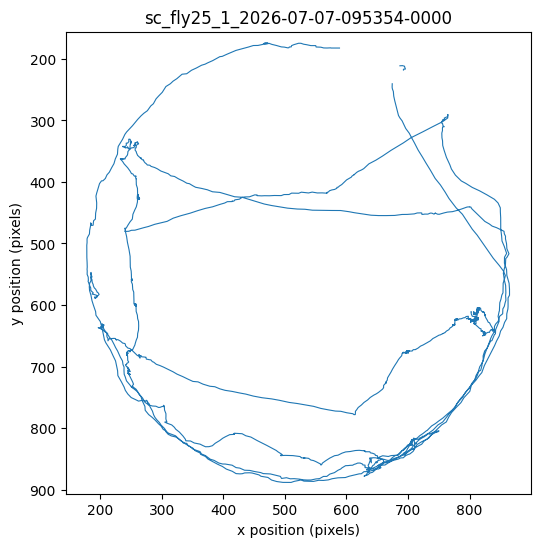

In [129]:
# Plot trajectory of one example fly


df = all_results[example_fly]["level0_interpolated_df"]

plt.figure(figsize=(6, 6))

plt.plot(
    df["center_x"],
    df["center_y"],
    linewidth=0.8,
)

# Image y increases downward.
plt.gca().invert_yaxis()

plt.axis("equal")

plt.xlabel("x position (pixels)")
plt.ylabel("y position (pixels)")

plt.title(example_fly)

plt.show()

In [86]:
# Level 1B: compute body angle and frame-to-frame angle change

def unwrap_angle_with_nan(angle_rad):
    """
    Unwrap an angle array separately within each continuous block of
    non-missing values.

    NaN gaps remain NaN and do not affect later valid segments.
    """

    angle_series = pd.Series(
        angle_rad,
        dtype=float,
    )

    valid = angle_series.notna()

    # Assign a different group number to every continuous valid/missing run.
    run_id = valid.ne(valid.shift()).cumsum()

    unwrapped = pd.Series(
        np.nan,
        index=angle_series.index,
        dtype=float,
    )

    for _, run in angle_series.groupby(run_id):

        # Skip missing runs.
        if run.isna().all():
            continue

        unwrapped.loc[run.index] = np.unwrap(
            run.to_numpy()
        )

    return unwrapped

In [87]:
# Level 1B: compute body angle and frame-to-frame angle change

for i, (fly_name, result) in enumerate(
    all_results.items(),
    start=1,
):
    print(
        f"[{i}/{len(all_results)}] "
        f"Computing body angle for {fly_name}"
    )

    # This is the working frame-by-frame dataframe after interpolation.
    df = result["level0_interpolated_df"]

    # --------------------------------------------------------
    # Construct the tail-to-head body vector
    # --------------------------------------------------------

    body_dx = df["head_x"] - df["tail_x"]

    # Image y-coordinates increase downward.
    # Negating dy converts the image coordinate system into the usual
    # Cartesian convention, where positive y points upward.
    body_dy = -(df["head_y"] - df["tail_y"])

    # --------------------------------------------------------
    # Compute body angle
    # --------------------------------------------------------

    # arctan2 returns the angle in radians from -pi to +pi.
    body_angle_rad = np.arctan2(
        body_dy,
        body_dx,
    )

    # Store the wrapped angle:
    # -pi to +pi radians, or -180 to +180 degrees.
    df["body_angle_rad"] = body_angle_rad

    df["body_angle_deg"] = np.degrees(
        body_angle_rad
    )

    # --------------------------------------------------------
    # Unwrap the angle before calculating frame-to-frame change
    # --------------------------------------------------------

    # np.unwrap prevents artificial jumps at the -180° / +180° boundary.
    #
    # Example:
    #     179° -> -179°
    #
    # should represent a +2° turn, not a -358° turn.
    # Using this function also avoid erroring out when deg = NaN
    body_angle_unwrapped_rad = unwrap_angle_with_nan(body_angle_rad)

    df["body_angle_unwrapped_rad"] = (
        body_angle_unwrapped_rad
    )

    df["body_angle_unwrapped_deg"] = np.degrees(
        body_angle_unwrapped_rad
    )

    # --------------------------------------------------------
    # Frame-to-frame change in body angle
    # --------------------------------------------------------

    # Current frame minus previous frame.
    # The first frame is NaN because no previous frame exists.
    df["delta_body_angle_rad"] = (
        df["body_angle_unwrapped_rad"].diff()
    )

    df["delta_body_angle_deg"] = (
        df["body_angle_unwrapped_deg"].diff()
    )

print("\nFinished computing body angles for all flies.")

[1/16] Computing body angle for sc_fly19_1_2026-07-01-155516-0000
[2/16] Computing body angle for sc_fly20_1_2026-07-01-164211-0000
[3/16] Computing body angle for sc_fly21_1_2026-07-01-172407-0000
[4/16] Computing body angle for sc_fly22_1_2026-07-01-175344-0000
[5/16] Computing body angle for sc_fly23_1_2026-07-02-093606-0000
[6/16] Computing body angle for sc_fly24_1_2026-07-02-102056-0000
[7/16] Computing body angle for sc_fly25_1_2026-07-07-095354-0000
[8/16] Computing body angle for sc_fly26_1_2026-07-07-102306-0000
[9/16] Computing body angle for sc_fly27_1_2026-07-10-105004-0000
[10/16] Computing body angle for sc_fly28_1_2026-07-10-111709-0000
[11/16] Computing body angle for sc_fly29_1_2026-07-10-115616-0000
[12/16] Computing body angle for sc_fly30_1_2026-07-10-122847-0000
[13/16] Computing body angle for sc_fly31_1_2026-07-10-140502-0000
[14/16] Computing body angle for sc_fly32_1_2026-07-10-143559-0000
[15/16] Computing body angle for sc_fly33_1_2026-07-10-151033-0000
[16/

In [88]:
# Level 1C: convert frame-to-frame angle change to deg/s


fps = 15

for i, (fly_name, result) in enumerate(
    all_results.items(),
    start=1,
):
    print(
        f"[{i}/{len(all_results)}] "
        f"Computing angular velocity for {fly_name}"
    )

    df = result["level0_interpolated_df"]

    df["angular_velocity_deg_s"] = (
        df["delta_body_angle_deg"] * fps
    )

print("\nFinished computing angular velocity.")

[1/16] Computing angular velocity for sc_fly19_1_2026-07-01-155516-0000
[2/16] Computing angular velocity for sc_fly20_1_2026-07-01-164211-0000
[3/16] Computing angular velocity for sc_fly21_1_2026-07-01-172407-0000
[4/16] Computing angular velocity for sc_fly22_1_2026-07-01-175344-0000
[5/16] Computing angular velocity for sc_fly23_1_2026-07-02-093606-0000
[6/16] Computing angular velocity for sc_fly24_1_2026-07-02-102056-0000
[7/16] Computing angular velocity for sc_fly25_1_2026-07-07-095354-0000
[8/16] Computing angular velocity for sc_fly26_1_2026-07-07-102306-0000
[9/16] Computing angular velocity for sc_fly27_1_2026-07-10-105004-0000
[10/16] Computing angular velocity for sc_fly28_1_2026-07-10-111709-0000
[11/16] Computing angular velocity for sc_fly29_1_2026-07-10-115616-0000
[12/16] Computing angular velocity for sc_fly30_1_2026-07-10-122847-0000
[13/16] Computing angular velocity for sc_fly31_1_2026-07-10-140502-0000
[14/16] Computing angular velocity for sc_fly32_1_2026-07-10

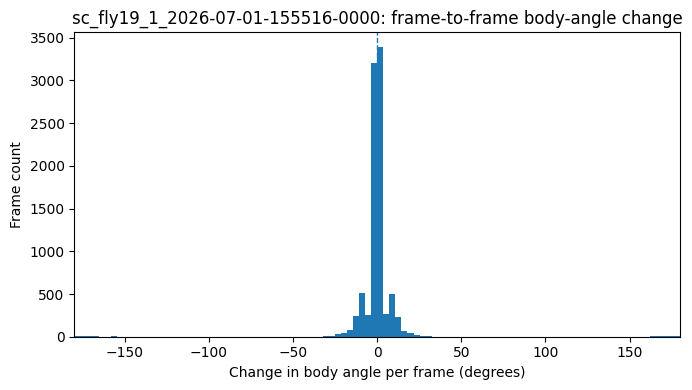

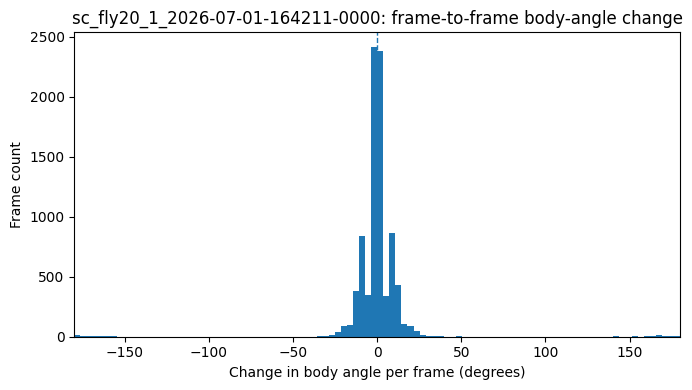

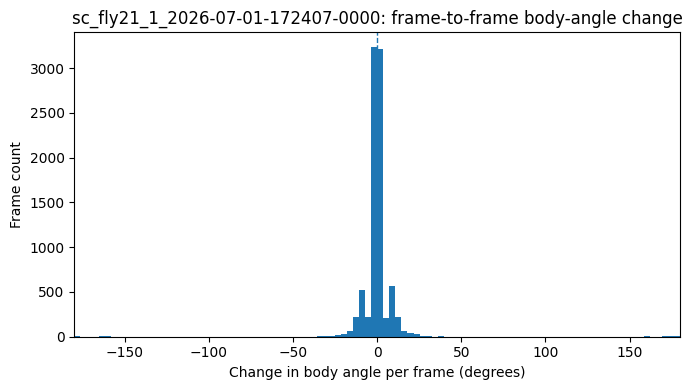

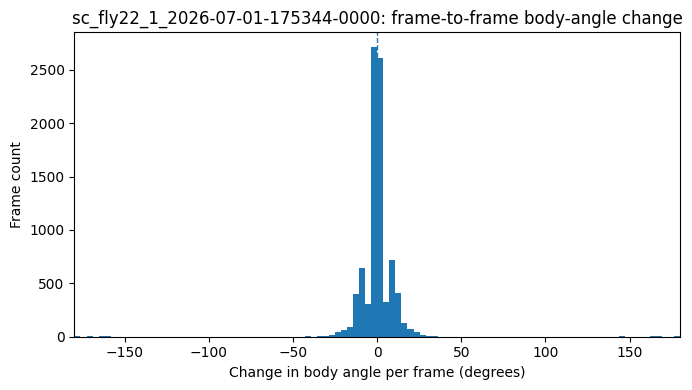

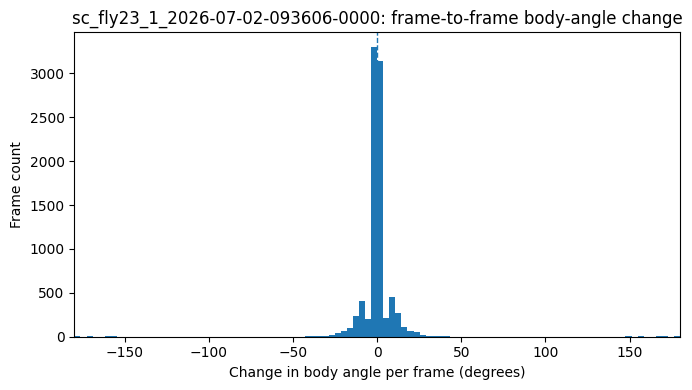

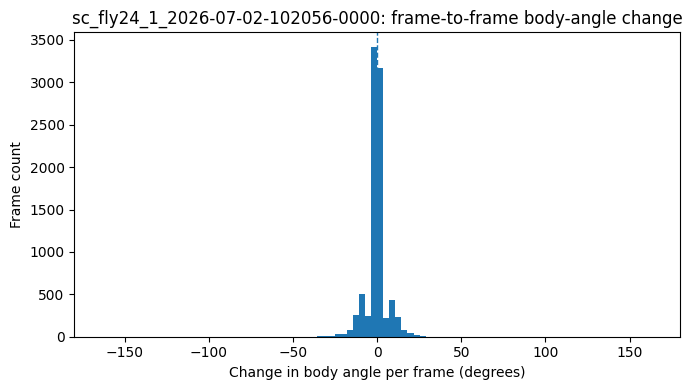

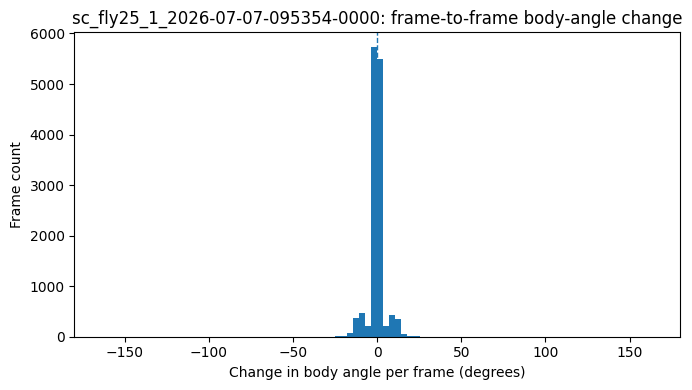

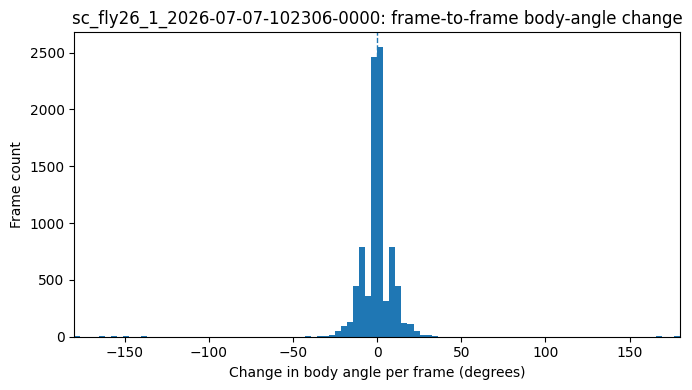

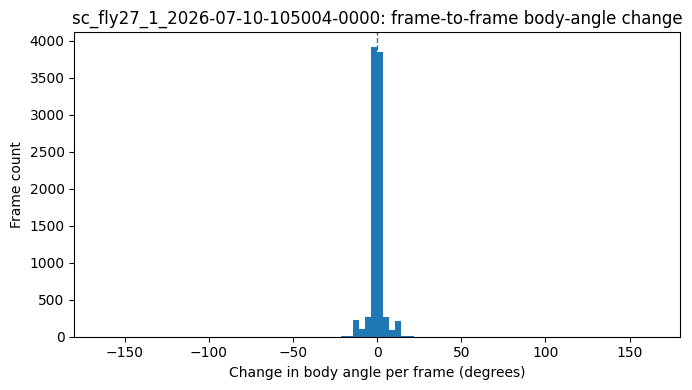

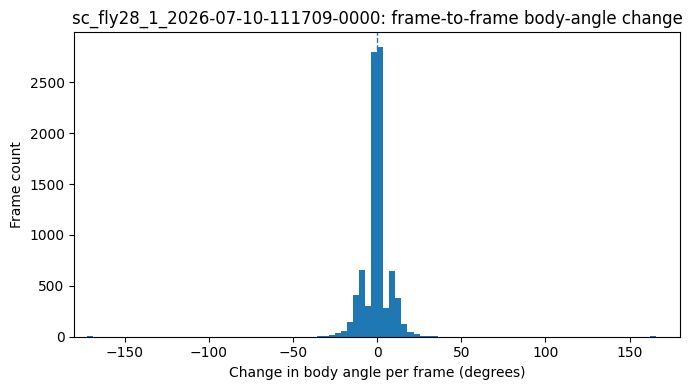

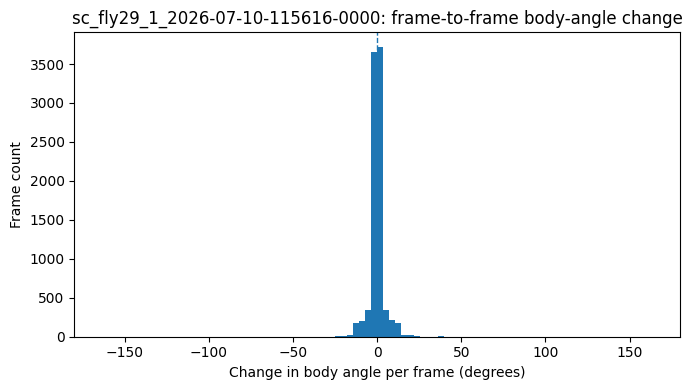

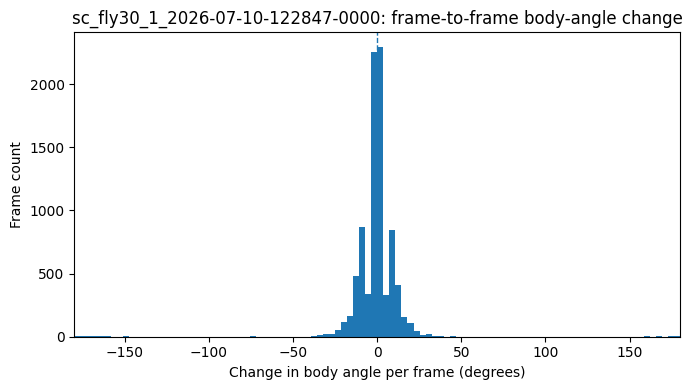

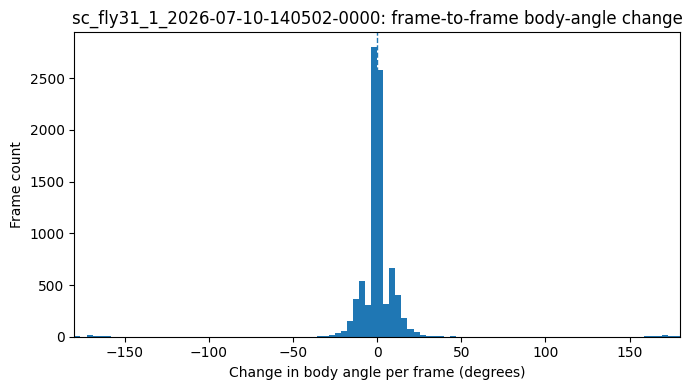

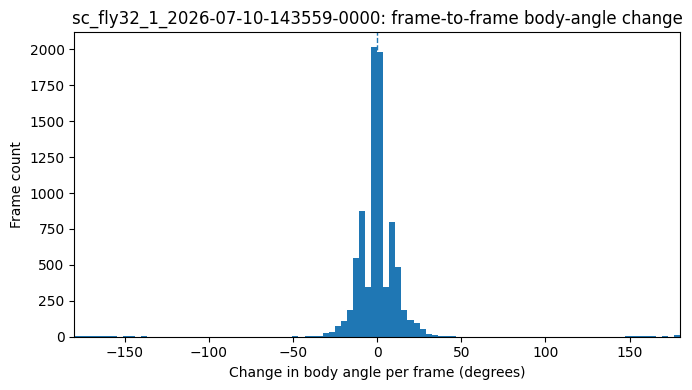

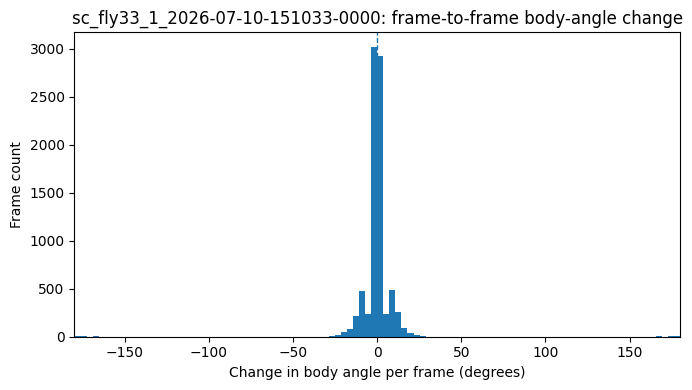

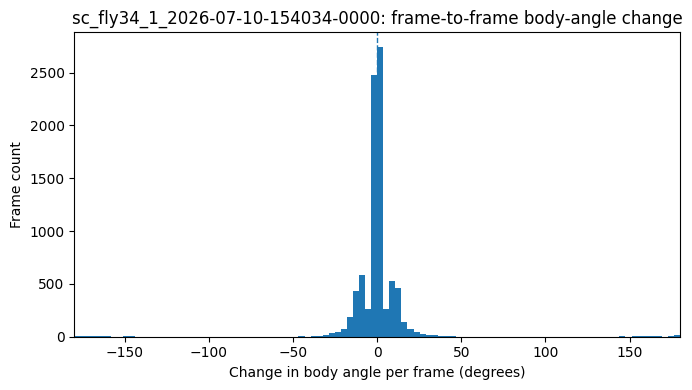

In [89]:
# Plot 1 version 1:
# histogram of frame-to-frame body-angle change

all_delta_angles = pd.concat(
    [
        result["level0_interpolated_df"]["delta_body_angle_deg"]
        for result in all_results.values()
    ],
    ignore_index=True,
).dropna()

max_abs_delta = np.nanmax(np.abs(all_delta_angles))

# Symmetric bins centered around 0.
bin_edges_delta = np.linspace(
    -max_abs_delta,
    max_abs_delta,
    101,
)

for fly_name, result in all_results.items():

    df = result["level0_interpolated_df"]

    values = df["delta_body_angle_deg"].dropna()

    plt.figure(figsize=(7, 4))

    plt.hist(
        values,
        bins=bin_edges_delta,
    )

    plt.axvline(
        0,
        linewidth=1,
        linestyle="--",
    )

    plt.xlim(
        -max_abs_delta,
        max_abs_delta,
    )

    plt.xlabel("Change in body angle per frame (degrees)")
    plt.ylabel("Frame count")
    plt.title(f"{fly_name}: frame-to-frame body-angle change")

    plt.tight_layout()
    plt.show()

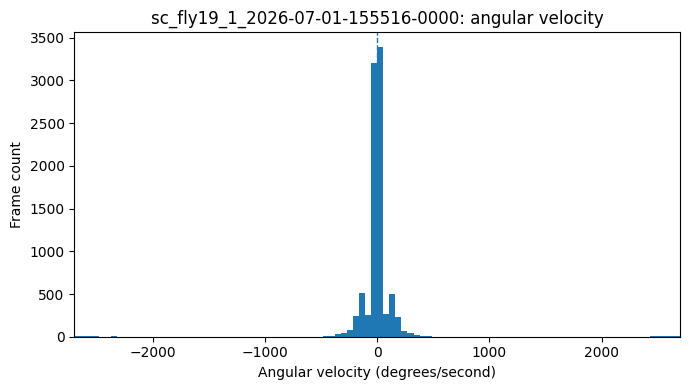

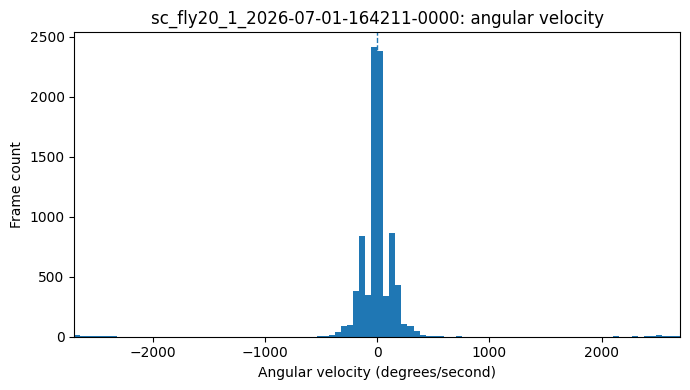

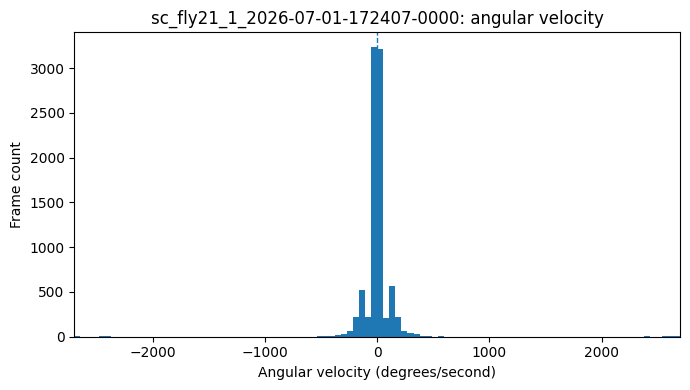

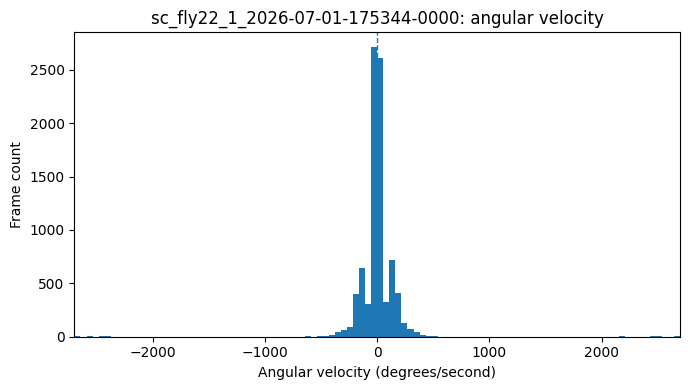

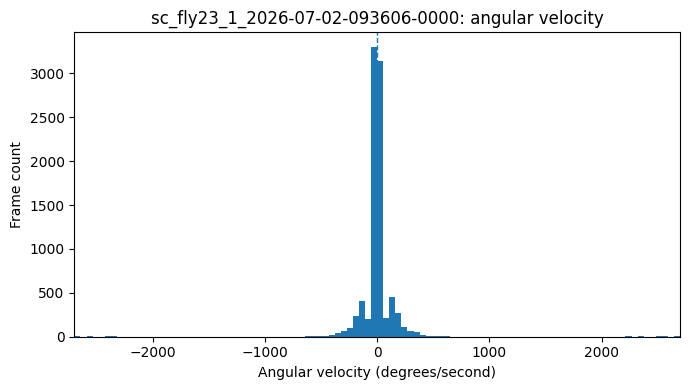

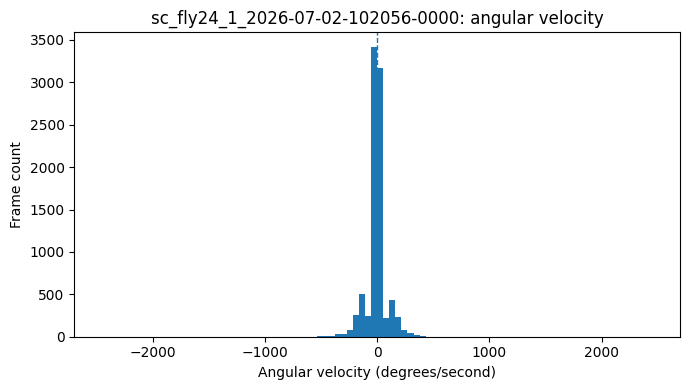

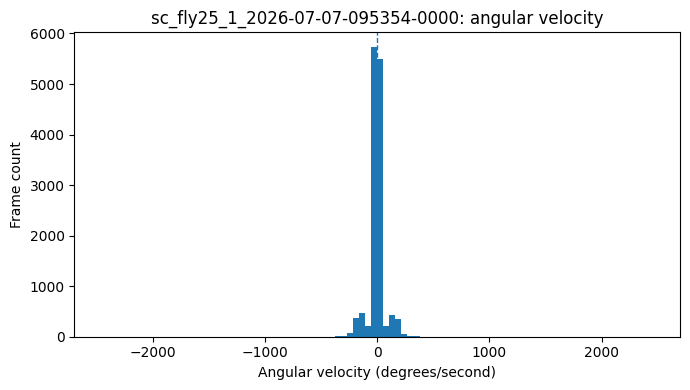

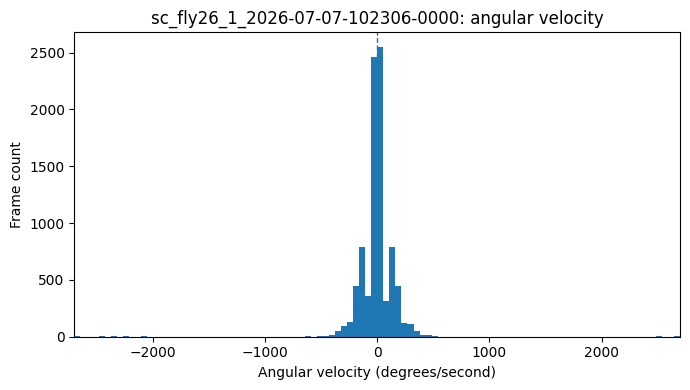

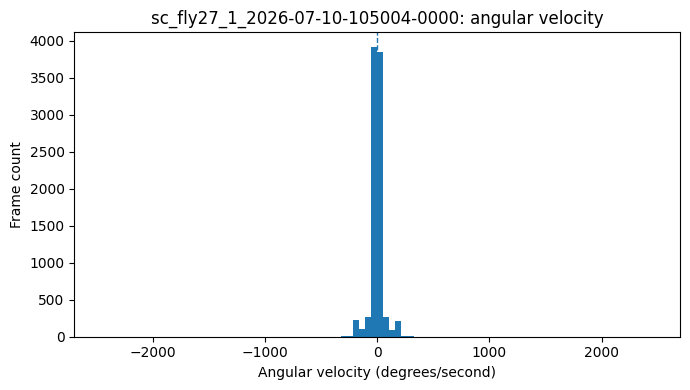

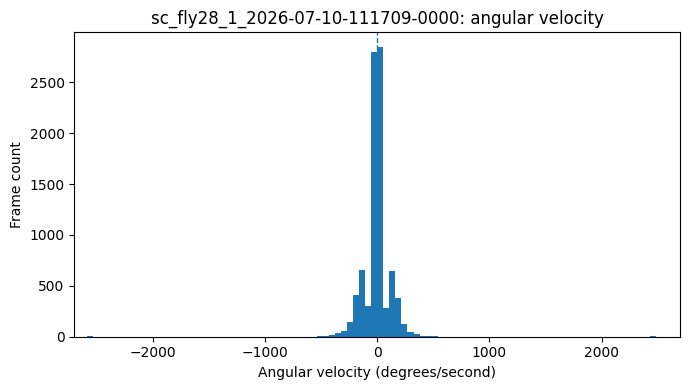

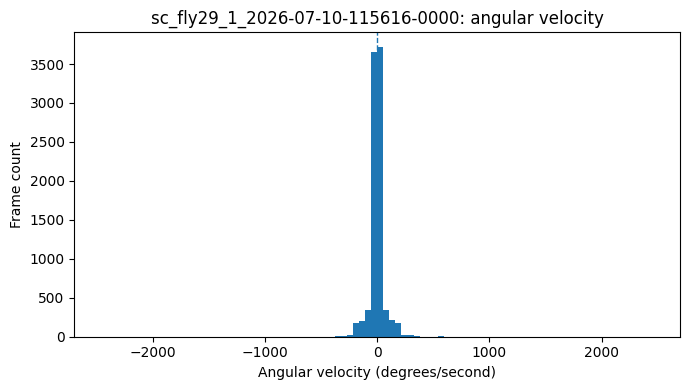

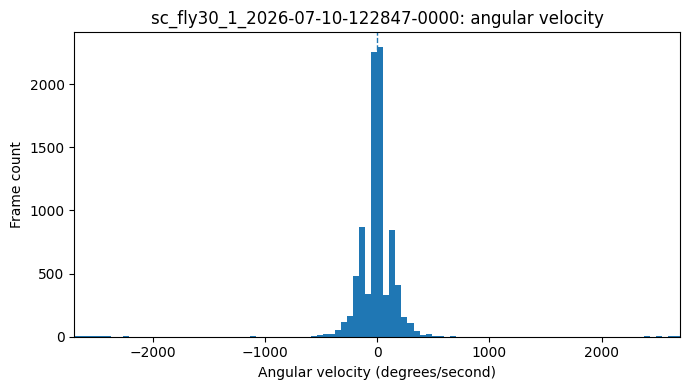

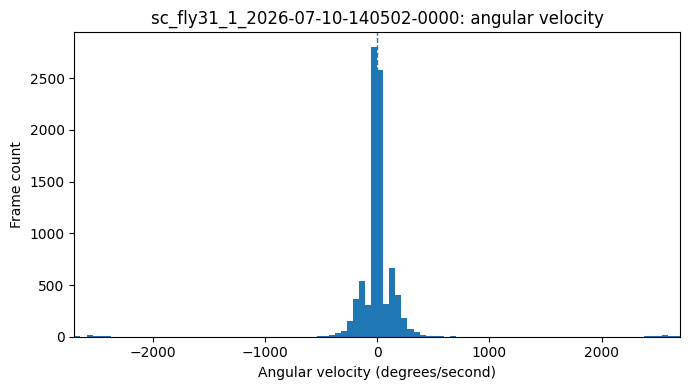

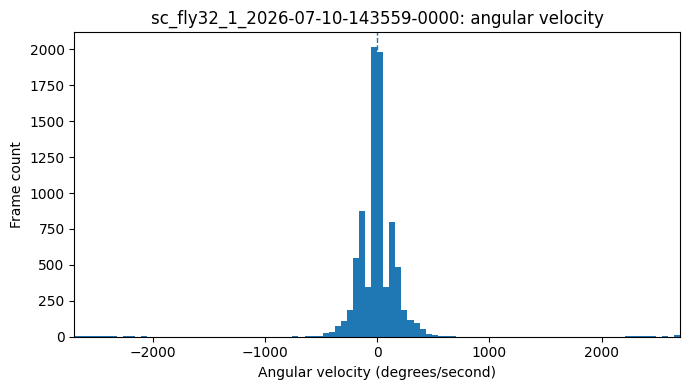

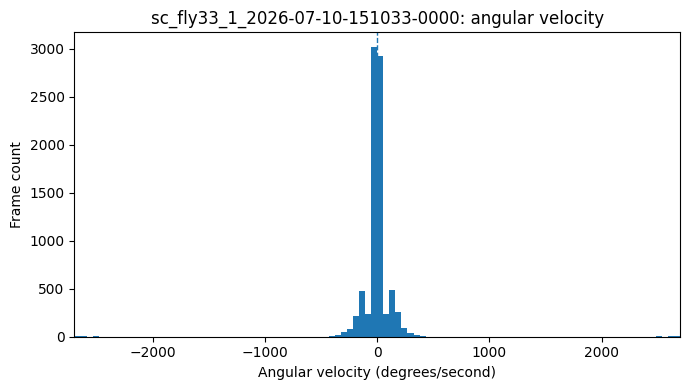

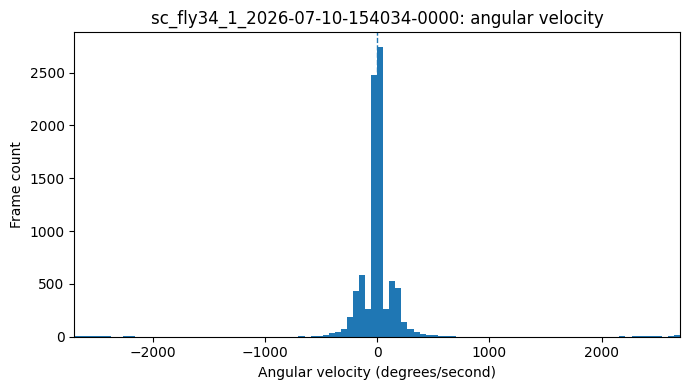

In [90]:
# Plot 1 version 2:
# histogram of angular velocity

all_angular_velocity = pd.concat(
    [
        result["level0_interpolated_df"]["angular_velocity_deg_s"]
        for result in all_results.values()
    ],
    ignore_index=True,
).dropna()

max_abs_velocity = np.nanmax(
    np.abs(all_angular_velocity)
)

bin_edges_velocity = np.linspace(
    -max_abs_velocity,
    max_abs_velocity,
    101,
)

for fly_name, result in all_results.items():

    df = result["level0_interpolated_df"]

    values = df["angular_velocity_deg_s"].dropna()

    plt.figure(figsize=(7, 4))

    plt.hist(
        values,
        bins=bin_edges_velocity,
    )

    plt.axvline(
        0,
        linewidth=1,
        linestyle="--",
    )

    plt.xlim(
        -max_abs_velocity,
        max_abs_velocity,
    )

    plt.xlabel("Angular velocity (degrees/second)")
    plt.ylabel("Frame count")
    plt.title(f"{fly_name}: angular velocity")

    plt.tight_layout()
    plt.show()

In [91]:
# Assign each tracked fly to its experimental group

base_video_folder = Path(
    r"C:\Users\FISHER-LAB\Documents"
    r"\camera GS3-U3-41C6NIR-C\no_cue"
)

group_video_folders = {
    "control": base_video_folder / "exr6-+",
    "kir": base_video_folder / "exr6-kir",
}

# Map each original video name, without ".avi", to its group.
video_group_map = {}

for group_name, folder in group_video_folders.items():

    for video_path in folder.glob("*.avi"):

        video_name = video_path.stem

        # Safety check in case identical filenames occur in both groups.
        if video_name in video_group_map:
            raise ValueError(
                f"Duplicate video name found in multiple groups: "
                f"{video_name}"
            )

        video_group_map[video_name] = group_name


# Add the group identity to all_results.
unmatched_flies = []

for fly_name, result in all_results.items():

    if fly_name not in video_group_map:
        unmatched_flies.append(fly_name)
        continue

    result["group"] = video_group_map[fly_name]


if unmatched_flies:
    raise ValueError(
        "These tracked files could not be matched to an original video:\n"
        + "\n".join(unmatched_flies)
    )


print("Group assignments:")

for fly_name, result in all_results.items():
    print(f"{result['group']:>7} : {fly_name}")

Group assignments:
control : sc_fly19_1_2026-07-01-155516-0000
    kir : sc_fly20_1_2026-07-01-164211-0000
control : sc_fly21_1_2026-07-01-172407-0000
    kir : sc_fly22_1_2026-07-01-175344-0000
control : sc_fly23_1_2026-07-02-093606-0000
    kir : sc_fly24_1_2026-07-02-102056-0000
control : sc_fly25_1_2026-07-07-095354-0000
    kir : sc_fly26_1_2026-07-07-102306-0000
control : sc_fly27_1_2026-07-10-105004-0000
    kir : sc_fly28_1_2026-07-10-111709-0000
control : sc_fly29_1_2026-07-10-115616-0000
    kir : sc_fly30_1_2026-07-10-122847-0000
control : sc_fly31_1_2026-07-10-140502-0000
    kir : sc_fly32_1_2026-07-10-143559-0000
control : sc_fly33_1_2026-07-10-151033-0000
    kir : sc_fly34_1_2026-07-10-154034-0000


In [92]:
# Make separate dictionaries for the two groups

grouped_results = {
    "control": {},
    "kir": {},
}

for fly_name, result in all_results.items():

    group_name = result["group"]

    grouped_results[group_name][fly_name] = result


print(
    f"Control flies: {len(grouped_results['control'])}\n"
    f"Kir flies:     {len(grouped_results['kir'])}"
)

Control flies: 8
Kir flies:     8


In [120]:
grouped_results['control'].keys()

dict_keys(['sc_fly19_1_2026-07-01-155516-0000', 'sc_fly21_1_2026-07-01-172407-0000', 'sc_fly23_1_2026-07-02-093606-0000', 'sc_fly25_1_2026-07-07-095354-0000', 'sc_fly27_1_2026-07-10-105004-0000', 'sc_fly29_1_2026-07-10-115616-0000', 'sc_fly31_1_2026-07-10-140502-0000', 'sc_fly33_1_2026-07-10-151033-0000'])

In [97]:
# Build group-average histograms

# Choose which measurement to histogram.
#
# Version 1:
# metric_column = "delta_body_angle_deg"
# x_axis_label = "Change in body angle per frame (degrees)"
#
# Version 2:
metric_column = "angular_velocity_deg_s"
x_axis_label = "Angular velocity (degrees/second)"


# Histogram settings.
# Adjust these later after examining the data distribution.
x_limit = 540
bin_width = 15

# Symmetric bin edges keep zero in the middle of the x-axis.
bin_edges = np.arange(
    -x_limit,
    x_limit + bin_width,
    bin_width,
)

bin_centers = (
    bin_edges[:-1] + bin_edges[1:]
) / 2


# Store each fly's histogram and each group's combined results.
individual_histograms = {
    "control": {},
    "kir": {},
}

group_histogram_results = {}


for group_name, flies in grouped_results.items():

    group_counts = []

    for fly_name, result in flies.items():

        df = result["level0_interpolated_df"]

        values = (
            df[metric_column]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy()
        )

        counts, _ = np.histogram(
            values,
            bins=bin_edges,
        )

        individual_histograms[group_name][fly_name] = counts
        group_counts.append(counts)

    if len(group_counts) == 0:
        raise ValueError(
            f"No flies were found in group: {group_name}"
        )

    # Shape:
    # number of flies × number of histogram bins
    group_counts = np.stack(group_counts)

    summed_counts = group_counts.sum(axis=0)
    mean_counts = group_counts.mean(axis=0)

    # Variation among flies, useful for an error band.
    if group_counts.shape[0] > 1:
        sem_counts = (
            group_counts.std(axis=0, ddof=1)
            / np.sqrt(group_counts.shape[0])
        )
    else:
        sem_counts = np.zeros_like(
            mean_counts,
            dtype=float,
        )

    group_histogram_results[group_name] = {
        "individual_counts": group_counts,
        "summed_counts": summed_counts,
        "mean_counts": mean_counts,
        "sem_counts": sem_counts,
        "n_flies": group_counts.shape[0],
    }

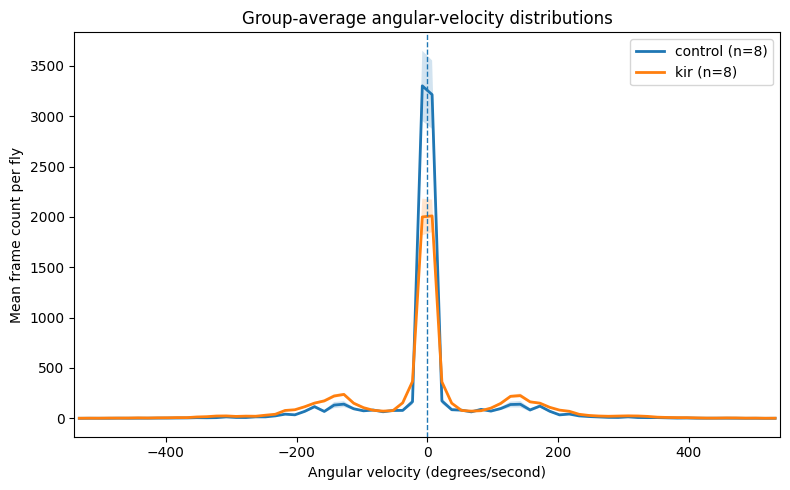

In [98]:
# Plot mean histogram for control and kir groups

plt.figure(figsize=(8, 5))

for group_name in ["control", "kir"]:

    result = group_histogram_results[group_name]

    mean_counts = result["mean_counts"]
    sem_counts = result["sem_counts"]

    plt.plot(
        bin_centers,
        mean_counts,
        linewidth=2,
        label=(
            f"{group_name} "
            f"(n={result['n_flies']})"
        ),
    )

    plt.fill_between(
        bin_centers,
        mean_counts - sem_counts,
        mean_counts + sem_counts,
        alpha=0.2,
    )


plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlim(-x_limit, x_limit)

plt.xlabel(x_axis_label)
plt.ylabel("Mean frame count per fly")
plt.title("Group-average angular-velocity distributions")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Level 1D: compute turning speed (absolute angular velocity)

for i, (fly_name, result) in enumerate(
    all_results.items(),
    start=1,
):

    print(
        f"[{i}/{len(all_results)}] "
        f"Computing turning speed for {fly_name}"
    )

    df = result["level0_interpolated_df"]

    df["turning_speed_deg_s"] = (
        df["angular_velocity_deg_s"].abs()
    )

print("\nFinished computing turning speed.")

[1/16] Computing turning speed for sc_fly19_1_2026-07-01-155516-0000
[2/16] Computing turning speed for sc_fly20_1_2026-07-01-164211-0000
[3/16] Computing turning speed for sc_fly21_1_2026-07-01-172407-0000
[4/16] Computing turning speed for sc_fly22_1_2026-07-01-175344-0000
[5/16] Computing turning speed for sc_fly23_1_2026-07-02-093606-0000
[6/16] Computing turning speed for sc_fly24_1_2026-07-02-102056-0000
[7/16] Computing turning speed for sc_fly25_1_2026-07-07-095354-0000
[8/16] Computing turning speed for sc_fly26_1_2026-07-07-102306-0000
[9/16] Computing turning speed for sc_fly27_1_2026-07-10-105004-0000
[10/16] Computing turning speed for sc_fly28_1_2026-07-10-111709-0000
[11/16] Computing turning speed for sc_fly29_1_2026-07-10-115616-0000
[12/16] Computing turning speed for sc_fly30_1_2026-07-10-122847-0000
[13/16] Computing turning speed for sc_fly31_1_2026-07-10-140502-0000
[14/16] Computing turning speed for sc_fly32_1_2026-07-10-143559-0000
[15/16] Computing turning spe

In [103]:
# Build individual and group histograms:
# turning speed in degrees per second

metric_column = "turning_speed_deg_s"

x_limit = 540
bin_width = 10

bin_edges_turning_speed = np.arange(
    0,
    x_limit + bin_width,
    bin_width,
)

bin_centers_turning_speed = (
    bin_edges_turning_speed[:-1]
    + bin_edges_turning_speed[1:]
) / 2


# Store each individual fly's histogram.
individual_turning_speed_histograms = {
    "control": {},
    "kir": {},
}

# Store group-level summaries.
group_turning_speed_histogram_results = {}


for group_name, flies in grouped_results.items():

    group_counts = []

    for fly_name, result in flies.items():

        df = result["level0_interpolated_df"]

        values = (
            df[metric_column]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy()
        )

        counts, _ = np.histogram(
            values,
            bins=bin_edges_turning_speed,
        )

        individual_turning_speed_histograms[
            group_name
        ][fly_name] = counts

        group_counts.append(counts)

    if len(group_counts) == 0:
        raise ValueError(
            f"No flies were found in group: {group_name}"
        )

    # Rows = flies; columns = histogram bins.
    group_counts = np.stack(group_counts)

    summed_counts = group_counts.sum(axis=0)
    mean_counts = group_counts.mean(axis=0)

    if group_counts.shape[0] > 1:
        sem_counts = (
            group_counts.std(axis=0, ddof=1)
            / np.sqrt(group_counts.shape[0])
        )
    else:
        sem_counts = np.zeros_like(
            mean_counts,
            dtype=float,
        )

    group_turning_speed_histogram_results[group_name] = {
        "individual_counts": group_counts,
        "summed_counts": summed_counts,
        "mean_counts": mean_counts,
        "sem_counts": sem_counts,
        "n_flies": group_counts.shape[0],
    }

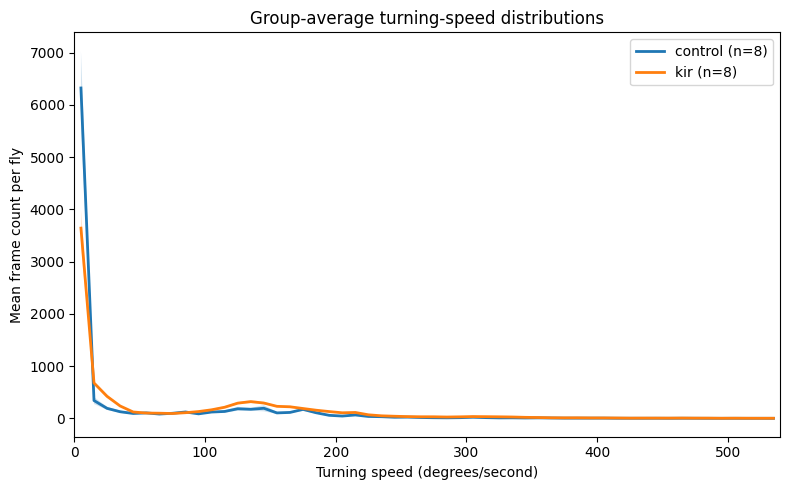

In [104]:
# Plot group-average turning-speed histograms
# ============================================================

plt.figure(figsize=(8, 5))

for group_name in ["control", "kir"]:

    result = group_turning_speed_histogram_results[group_name]

    mean_counts = result["mean_counts"]
    sem_counts = result["sem_counts"]

    plt.plot(
        bin_centers_turning_speed,
        mean_counts,
        linewidth=2,
        label=f"{group_name} (n={result['n_flies']})",
    )

    plt.fill_between(
        bin_centers_turning_speed,
        mean_counts - sem_counts,
        mean_counts + sem_counts,
        alpha=0.2,
    )

plt.xlim(0, x_limit)

plt.xlabel("Turning speed (degrees/second)")
plt.ylabel("Mean frame count per fly")
plt.title("Group-average turning-speed distributions")

plt.legend()
plt.tight_layout()
plt.show()

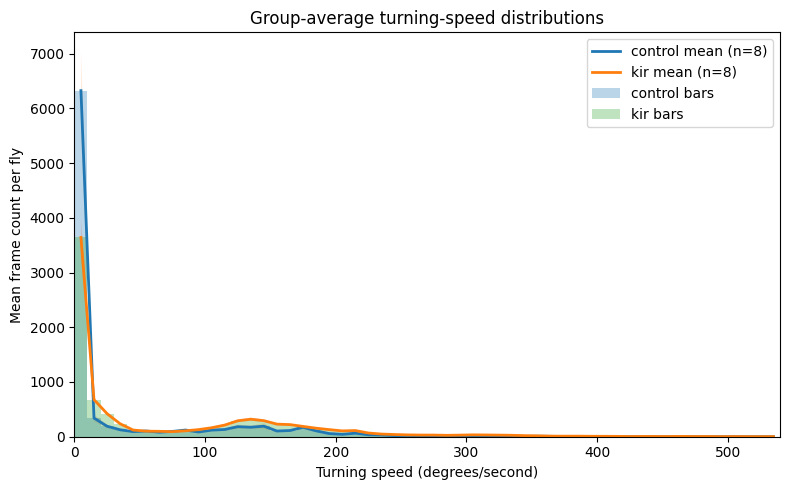

In [124]:
# Plot group-average turning-speed histograms
# with overlapping bars + mean lines + SEM
# ============================================================

plt.figure(figsize=(8, 5))
colors = {
    "control": "tab:blue",
    "kir": "tab:red",
}
bar_width = np.diff(bin_edges_turning_speed)[0]

for group_name in ["control", "kir"]:

    result = group_turning_speed_histogram_results[group_name]

    mean_counts = result["mean_counts"]
    sem_counts = result["sem_counts"]

    # Overlapping histogram bars.
    # Both groups use the exact same bin centers and widths.
    plt.bar(
        bin_centers_turning_speed,
        mean_counts,
        width=bar_width,
        alpha=0.3,
        align="center",
        label=f"{group_name} bars",
    )

    # Mean line on top of the bars.
    plt.plot(
        bin_centers_turning_speed,
        mean_counts,
        linewidth=2,
        label=f"{group_name} mean (n={result['n_flies']})",
    )

    # SEM around the mean.
    plt.fill_between(
        bin_centers_turning_speed,
        mean_counts - sem_counts,
        mean_counts + sem_counts,
        alpha=0.15,
    )

plt.xlim(0, x_limit)

plt.xlabel("Turning speed (degrees/second)")
plt.ylabel("Mean frame count per fly")
plt.title("Group-average turning-speed distributions")

plt.legend()
plt.tight_layout()
plt.show()

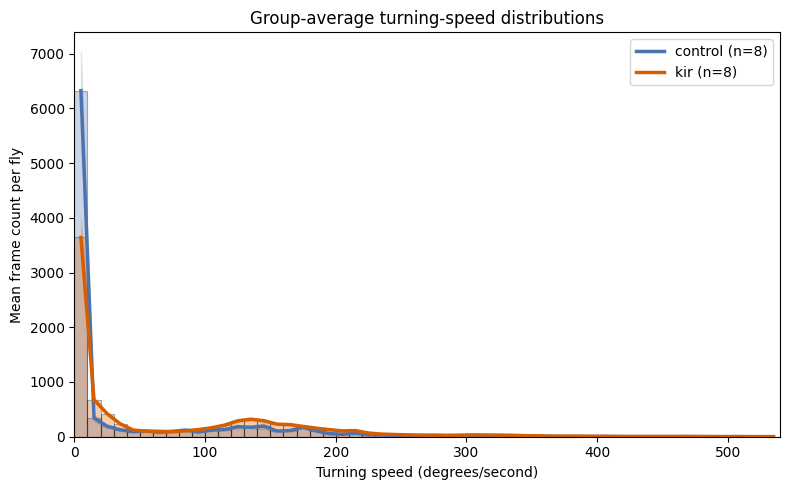

In [125]:
plt.figure(figsize=(8, 5))

colors = {
    "control": "#4C72B0",   # blue
    "kir": "#D55E00",       # reddish orange
}

bar_width = np.diff(bin_edges_turning_speed)[0]

for group_name in ["control", "kir"]:

    color = colors[group_name]

    result = group_turning_speed_histogram_results[group_name]

    mean_counts = result["mean_counts"]
    sem_counts = result["sem_counts"]

    # Histogram bars
    plt.bar(
        bin_centers_turning_speed,
        mean_counts,
        width=bar_width,
        align="center",
        color=color,
        alpha=0.30,
        edgecolor="black",      # <-- black outline
        linewidth=0.8,          # thickness of outline
    )

    # Mean line
    plt.plot(
        bin_centers_turning_speed,
        mean_counts,
        color=color,
        linewidth=2.5,
        label=f"{group_name} (n={result['n_flies']})",
    )

    # SEM
    plt.fill_between(
        bin_centers_turning_speed,
        mean_counts - sem_counts,
        mean_counts + sem_counts,
        color=color,
        alpha=0.15,
    )

plt.xlim(0, x_limit)

plt.xlabel("Turning speed (degrees/second)")
plt.ylabel("Mean frame count per fly")
plt.title("Group-average turning-speed distributions")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Level 1E: compute unsmoothed translational speed

fps = 15

for i, (fly_name, result) in enumerate(
    all_results.items(),
    start=1,
):
    print(
        f"[{i}/{len(all_results)}] "
        f"Computing unsmoothed center speed for {fly_name}"
    )

    df = result["level0_interpolated_df"]

    # Center displacement from the previous frame.
    df["delta_center_x_px"] = df["center_x"].diff()
    df["delta_center_y_px"] = df["center_y"].diff()

    df["center_displacement_px"] = np.sqrt(
        df["delta_center_x_px"] ** 2
        + df["delta_center_y_px"] ** 2
    )

    # Convert pixels/frame to pixels/second.
    df["center_speed_px_s"] = (
        df["center_displacement_px"] * fps
    )

print("\nFinished computing unsmoothed center speed.")

[1/16] Computing unsmoothed center speed for sc_fly19_1_2026-07-01-155516-0000
[2/16] Computing unsmoothed center speed for sc_fly20_1_2026-07-01-164211-0000
[3/16] Computing unsmoothed center speed for sc_fly21_1_2026-07-01-172407-0000
[4/16] Computing unsmoothed center speed for sc_fly22_1_2026-07-01-175344-0000
[5/16] Computing unsmoothed center speed for sc_fly23_1_2026-07-02-093606-0000
[6/16] Computing unsmoothed center speed for sc_fly24_1_2026-07-02-102056-0000
[7/16] Computing unsmoothed center speed for sc_fly25_1_2026-07-07-095354-0000
[8/16] Computing unsmoothed center speed for sc_fly26_1_2026-07-07-102306-0000
[9/16] Computing unsmoothed center speed for sc_fly27_1_2026-07-10-105004-0000
[10/16] Computing unsmoothed center speed for sc_fly28_1_2026-07-10-111709-0000
[11/16] Computing unsmoothed center speed for sc_fly29_1_2026-07-10-115616-0000
[12/16] Computing unsmoothed center speed for sc_fly30_1_2026-07-10-122847-0000
[13/16] Computing unsmoothed center speed for sc_

In [106]:
# Summarize unsmoothed center speed for every fly

center_speed_summary_rows = []

for fly_name, result in all_results.items():

    df = result["level0_interpolated_df"]

    speed = (
        df["center_speed_px_s"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    center_speed_summary_rows.append({
        "fly_name": fly_name,
        "group": result["group"],
        "n_valid_frames": len(speed),
        "mean_speed_px_s": speed.mean(),
        "median_speed_px_s": speed.median(),
        "speed_std_px_s": speed.std(),
        "speed_p90_px_s": speed.quantile(0.90),
        "speed_p95_px_s": speed.quantile(0.95),
        "speed_p99_px_s": speed.quantile(0.99),
        "max_speed_px_s": speed.max(),
    })

center_speed_summary_df = pd.DataFrame(
    center_speed_summary_rows
)

center_speed_summary_df

,fly_name,group,n_valid_frames,mean_speed_px_s,median_speed_px_s,speed_std_px_s,speed_p90_px_s,speed_p95_px_s,speed_p99_px_s,max_speed_px_s
0,sc_fly19_1_2026-07-01-155516-0000,control,8999,21.812359,2.191207,39.052272,65.541456,97.061894,146.494328,1403.449742
1,sc_fly20_1_2026-07-01-164211-0000,kir,8616,67.629372,65.949688,53.163549,135.071113,156.313280,189.472237,348.449618
2,sc_fly21_1_2026-07-01-172407-0000,control,8750,22.644857,1.804220,41.811041,75.394430,115.829370,174.129463,1555.381432
3,sc_fly22_1_2026-07-01-175344-0000,kir,8701,40.268601,30.074829,40.905243,99.039681,118.198304,141.718914,303.597843
4,sc_fly23_1_2026-07-02-093606-0000,control,8820,33.126857,2.692052,61.100205,115.624316,152.787865,220.787436,1757.845938
5,sc_fly24_1_2026-07-02-102056-0000,kir,8817,34.551095,1.896793,51.355367,118.913528,134.131524,176.616511,1063.805705
6,sc_fly25_1_2026-07-07-095354-0000,control,13446,13.700203,1.152975,30.713334,44.581765,74.341578,151.271123,346.939655
7,sc_fly26_1_2026-07-07-102306-0000,kir,8809,59.083538,53.632912,53.682411,132.239470,156.954182,200.350169,303.580282
8,sc_fly27_1_2026-07-10-105004-0000,control,8980,6.980613,1.140397,22.870237,21.038290,23.319038,107.486510,381.195106
9,sc_fly28_1_2026-07-10-111709-0000,kir,8853,43.683810,24.167615,50.757954,121.182290,142.274612,192.673062,335.701616


In [108]:
# Choose shared histogram bins for unsmoothed center speed
# ============================================================

all_center_speed = pd.concat(
    [
        result["level0_interpolated_df"]["center_speed_px_s"]
        for result in all_results.values()
    ],
    ignore_index=True,
)

all_center_speed = (
    all_center_speed
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Use a percentile so isolated tracking errors do not make
# the histogram x-axis extremely wide.
center_speed_x_limit = float(
    all_center_speed.quantile(0.995)
)

# Round upward to the nearest 10 px/s.
center_speed_x_limit = (
    np.ceil(center_speed_x_limit / 10) * 10
)

center_speed_bin_width = 5

center_speed_bin_edges = np.arange(
    0,
    center_speed_x_limit + center_speed_bin_width,
    center_speed_bin_width,
)

center_speed_bin_centers = (
    center_speed_bin_edges[:-1]
    + center_speed_bin_edges[1:]
) / 2

print(
    f"Histogram x-axis limit: "
    f"{center_speed_x_limit:.1f} px/s"
)

Histogram x-axis limit: 250.0 px/s


In [110]:
# Build individual and group histograms:
# unsmoothed center speed

individual_center_speed_histograms = {
    "control": {},
    "kir": {},
}

group_center_speed_histogram_results = {}


for group_name, flies in grouped_results.items():

    group_counts = []

    for fly_name, result in flies.items():

        df = result["level0_interpolated_df"]

        values = (
            df["center_speed_px_s"]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy()
        )

        counts, _ = np.histogram(
            values,
            bins=center_speed_bin_edges,
        )

        individual_center_speed_histograms[
            group_name
        ][fly_name] = counts

        group_counts.append(counts)

    if len(group_counts) == 0:
        raise ValueError(
            f"No flies were found in group: {group_name}"
        )

    # Rows = flies; columns = speed bins.
    group_counts = np.stack(group_counts)

    summed_counts = group_counts.sum(axis=0)
    mean_counts = group_counts.mean(axis=0)

    if group_counts.shape[0] > 1:
        sem_counts = (
            group_counts.std(axis=0, ddof=1)
            / np.sqrt(group_counts.shape[0])
        )
    else:
        sem_counts = np.zeros_like(
            mean_counts,
            dtype=float,
        )

    group_center_speed_histogram_results[group_name] = {
        "individual_counts": group_counts,
        "summed_counts": summed_counts,
        "mean_counts": mean_counts,
        "sem_counts": sem_counts,
        "n_flies": group_counts.shape[0],
    }

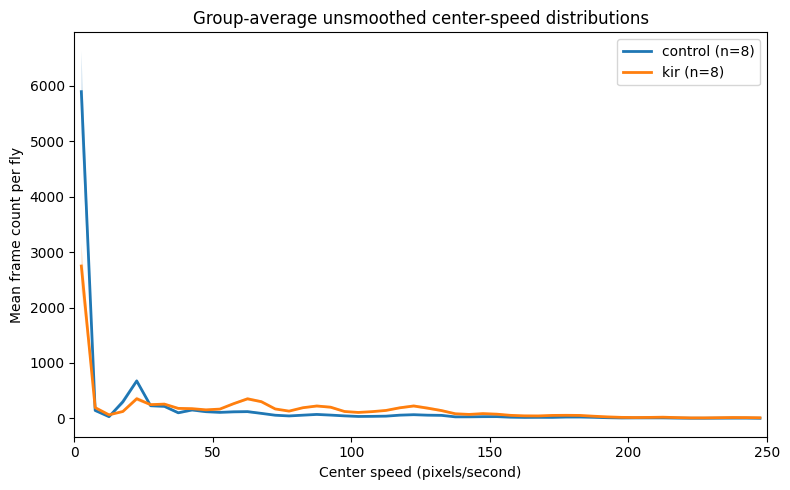

In [111]:
# Plot group-average unsmoothed center-speed distributions

plt.figure(figsize=(8, 5))

for group_name in ["control", "kir"]:

    result = group_center_speed_histogram_results[
        group_name
    ]

    mean_counts = result["mean_counts"]
    sem_counts = result["sem_counts"]

    plt.plot(
        center_speed_bin_centers,
        mean_counts,
        linewidth=2,
        label=f"{group_name} (n={result['n_flies']})",
    )

    plt.fill_between(
        center_speed_bin_centers,
        mean_counts - sem_counts,
        mean_counts + sem_counts,
        alpha=0.2,
    )

plt.xlim(0, center_speed_x_limit)

plt.xlabel("Center speed (pixels/second)")
plt.ylabel("Mean frame count per fly")
plt.title(
    "Group-average unsmoothed center-speed distributions"
)

plt.legend()
plt.tight_layout()
plt.show()

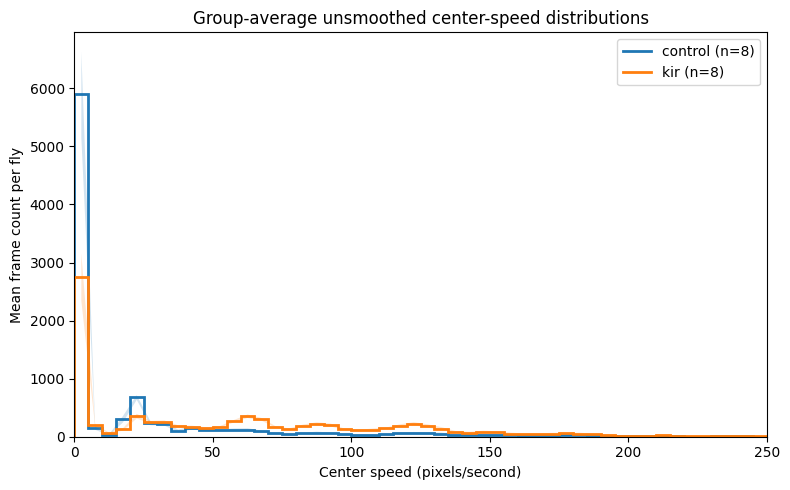

In [114]:
# Plot group-average unsmoothed center-speed distributions

plt.figure(figsize=(8, 5))

for group_name in ["control", "kir"]:

    result = group_center_speed_histogram_results[
        group_name
    ]

    mean_counts = result["mean_counts"]
    sem_counts = result["sem_counts"]

    plt.stairs(
    mean_counts,
    center_speed_bin_edges,
    label=f"{group_name} (n={result['n_flies']})",
    linewidth=2,
    )

    plt.fill_between(
        center_speed_bin_centers,
        mean_counts - sem_counts,
        mean_counts + sem_counts,
        alpha=0.2,
    )

plt.xlim(0, center_speed_x_limit)

plt.xlabel("Center speed (pixels/second)")
plt.ylabel("Mean frame count per fly")
plt.title(
    "Group-average unsmoothed center-speed distributions"
)

plt.legend()
plt.tight_layout()
plt.show()



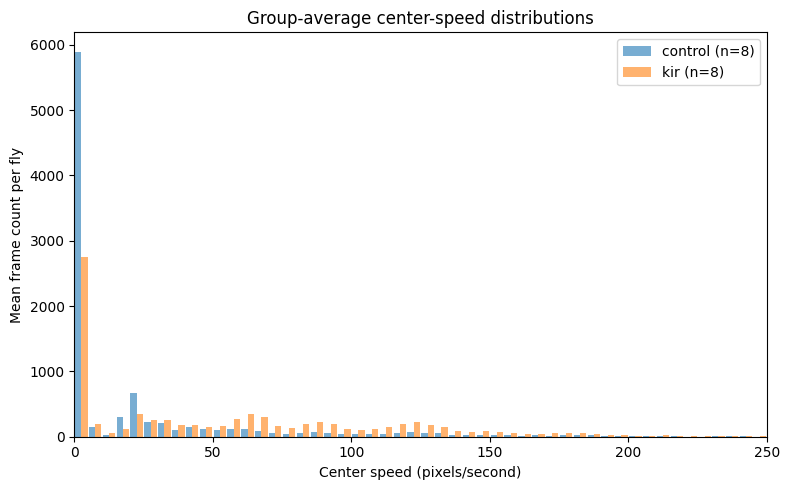

In [116]:
plt.figure(figsize=(8, 5))

bar_width = center_speed_bin_width * 0.45

# Control
control_mean = group_center_speed_histogram_results["control"]["mean_counts"]

plt.bar(
    center_speed_bin_centers - bar_width/2,
    control_mean,
    width=bar_width,
    alpha=0.6,
    label=f"control (n={group_center_speed_histogram_results['control']['n_flies']})",
)

# Kir
kir_mean = group_center_speed_histogram_results["kir"]["mean_counts"]

plt.bar(
    center_speed_bin_centers + bar_width/2,
    kir_mean,
    width=bar_width,
    alpha=0.6,
    label=f"kir (n={group_center_speed_histogram_results['kir']['n_flies']})",
)

plt.xlabel("Center speed (pixels/second)")
plt.ylabel("Mean frame count per fly")
plt.title("Group-average center-speed distributions")

plt.xlim(0, center_speed_x_limit)

plt.legend()
plt.tight_layout()
plt.show()

below are codes for running inference on one video as test

In [ ]:
# a one video check
video_path = selected_videos[0]

output_path = output_folder / f"{video_path.stem}.predictions.slp"

command = [
    sleap_track,
    str(video_path),

    # models
    "--model", centroid_model,
    "--model", centered_instance_model,

    # tracker settings
    "--tracking.tracker", "simple",
    "--tracking.similarity", "centroid",
    "--tracking.match", "hungarian",
    "--tracking.robust", "1",

    # one fly only
    "--tracking.max_tracking", "1",
    "--tracking.max_tracks", "1",

    # use GPU
    "--first-gpu",

    # output
    "--output", str(output_path),
]

print("Running command:\n")
print(" ".join(command))
print()

subprocess.run(command, check=True)

print("\nInference finished!")
print(f"Output saved to:\n{output_path}")

Running command:

C:\Users\FISHER-LAB\AppData\Local\Programs\Python\Python313\Scripts\sleap-track.EXE C:\Users\FISHER-LAB\Documents\camera GS3-U3-41C6NIR-C\no_cue\exr6-+\sc_fly19_1_2026-07-01-155516-0000.avi --model C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\fly19_model\models\260708_165803.centroid.n=25 --model C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\fly19_model\models\260708_180447.centered_instance.n=25 --tracking.tracker simple --tracking.similarity centroid --tracking.match hungarian --tracking.robust 1 --tracking.max_tracking 1 --tracking.max_tracks 1 --first-gpu --output C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\test\sc_fly19_1_2026-07-01-155516-0000.predictions.slp


Inference finished!
Output saved to:
C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\test\sc_fly19_1_2026-07-01-155516-0000.predictions.slp


In [21]:
df = 0

In [22]:
from pathlib import Path
import sleap_io as sio

slp_path = Path(
    r"C:\Users\FISHER-LAB\Documents\SLEAP\no_cue\test"
) / f"{selected_videos[0].stem}.predictions.slp"

labels = sio.load_slp(slp_path)

print(labels)

Labels(labeled_frames=8997, videos=1, skeletons=1, tracks=1, suggestions=0, sessions=0)


In [23]:
# ---------- Level 0A: select one loaded SLEAP project ----------
video = labels.videos[0]
skeleton = labels.skeletons[0]

video_n_frames = video.shape[0]

print("SLEAP project:")
print(labels)

print("\nLinked video:")
print(video)

print("\nVideo frame count:")
print(video_n_frames)

print("\nFrames containing labels/predictions:")
print(len(labels))

print("\nSkeleton:")
print(skeleton)

print("\nTracks:")
print(labels.tracks)

SLEAP project:
Labels(labeled_frames=8997, videos=1, skeletons=1, tracks=1, suggestions=0, sessions=0)

Linked video:
Video(filename="C:/Users/FISHER-LAB/Documents/camera GS3-U3-41C6NIR-C/no_cue/exr6-+/sc_fly19_1_2026-07-01-155516-0000.avi", shape=(9000, 1024, 1024, 1), backend=MediaVideo)

Video frame count:
9000

Frames containing labels/predictions:
8997

Skeleton:
Skeleton(nodes=["head", "tail"], edges=[(0, 1)])

Tracks:
[Track(name='track_0')]


In [24]:
# ---------- Level 0B: convert SLEAP tracking into a dataframe ----------

# Start with one empty row for every frame in the original video.
# This preserves the true timing even if SLEAP has no prediction for some frames.
df = pd.DataFrame({
    "frame_idx": np.arange(video_n_frames, dtype=int),
    "instance_score": np.nan,
    "tracking_score": np.nan,
    "head_x": np.nan,
    "head_y": np.nan,
    "head_score": np.nan,
    "tail_x": np.nan,
    "tail_y": np.nan,
    "tail_score": np.nan,
})

# Use frame_idx as the temporary dataframe index so each SLEAP prediction
# can be inserted into its correct original video frame.
df = df.set_index("frame_idx")


for labeled_frame in labels:
    frame_idx = labeled_frame.frame_idx

    # Leave this frame as NaN if no animal instance was predicted.
    if len(labeled_frame.instances) == 0:
        continue

    # There is only one fly, so take the first instance.
    inst = labeled_frame.instances[0]

    df.loc[frame_idx, "instance_score"] = inst.score
    df.loc[frame_idx, "tracking_score"] = inst.tracking_score

    # Extract coordinates and confidence score for each skeleton node.
    for point in inst.points:
        point_name = str(point[4])   # expected: "head" or "tail"
        x, y = point[0]
        point_score = point[1]

        # This guards against unexpected additional node names.
        if point_name not in {"head", "tail"}:
            continue

        df.loc[frame_idx, f"{point_name}_x"] = x
        df.loc[frame_idx, f"{point_name}_y"] = y
        df.loc[frame_idx, f"{point_name}_score"] = point_score


# Restore frame_idx as a normal column.
df = df.reset_index()

df.head()

,frame_idx,instance_score,tracking_score,head_x,head_y,head_score,tail_x,tail_y,tail_score
0,0,0.984774,1.000000,592.417175,800.747620,0.992865,568.714844,800.921875,0.989961
1,1,0.984115,0.771524,592.361511,800.772522,0.989292,568.635742,800.936523,1.005169
2,2,0.981561,0.528205,592.304443,800.826172,0.986320,568.574036,801.013367,1.010376
3,3,0.985041,0.274235,588.582947,804.691040,1.001375,568.336365,800.565918,0.943889
4,4,0.993752,0.000003,584.849304,808.580139,1.007182,565.378784,800.142700,0.887376


In [25]:
df = interpolate_short_tracking_gaps(
    df,
    max_gap_frames=3,
)

In [26]:
print("Originally missing frames:")
print(df["was_missing_originally"].sum())

print("\nInterpolated frames:")
print(df["was_interpolated"].sum())

print("\nFrames still missing after interpolation:")
print(
    df[["head_x", "head_y", "tail_x", "tail_y"]]
    .isna()
    .any(axis=1)
    .sum()
)

Originally missing frames:
8

Interpolated frames:
8

Frames still missing after interpolation:
0


In [27]:
df.loc[
    df["was_missing_originally"],
    [
        "frame_idx",
        "head_x",
        "head_y",
        "tail_x",
        "tail_y",
        "was_interpolated",
        "interpolation_gap_length",
    ],
]

,frame_idx,head_x,head_y,tail_x,tail_y,was_interpolated,interpolation_gap_length
2060,2060,574.688812,220.398117,555.147980,223.030869,True,1
2070,2070,545.900879,233.894597,528.380046,235.876668,True,2
2071,2071,547.182678,235.147257,528.539388,234.272807,True,2
2080,2080,546.685608,273.491592,541.351929,256.734894,True,3
2081,2081,548.611084,278.528595,542.543213,261.921295,True,3
2082,2082,550.536560,283.565598,543.734497,267.107697,True,3
8948,8948,600.568197,245.870356,590.322693,232.299906,True,2
8949,8949,600.691081,247.215230,591.972412,232.386205,True,2


In [28]:
df["center_x"] = (df["head_x"] + df["tail_x"]) / 2
df["center_y"] = (df["head_y"] + df["tail_y"]) / 2

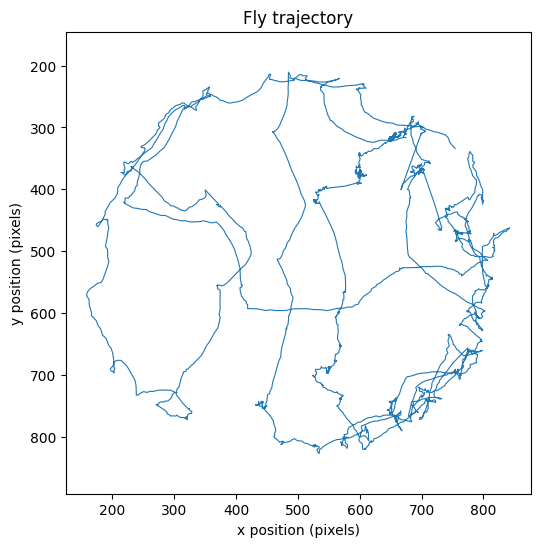

In [29]:
plt.figure(figsize=(6, 6))
plt.plot(
    df["center_x"],
    df["center_y"],
    linewidth=0.8,
)

# Image y-coordinates increase downward, so invert the y-axis
# to make the trajectory match how the video appears.
plt.gca().invert_yaxis()

plt.axis("equal")
plt.xlabel("x position (pixels)")
plt.ylabel("y position (pixels)")
plt.title("Fly trajectory")
plt.show()

# old codes (level 0 - 3...)

In [126]:
example_fly = control["fly19_1"]

In [127]:
print(example_fly.videos)
print(example_fly.skeletons)
print(example_fly.tracks)
len(example_fly)    #<-- number of labeled frames.

[Video(filename="C:/Users/FISHER-LAB/Documents/camera GS3-U3-41C6NIR-C/no_cue/exr6-+/sc_fly19_1_2026-07-01-155516-0000.avi", shape=(9000, 1024, 1024, 1), backend=MediaVideo)]
[Skeleton(nodes=["head", "tail"], edges=[(0, 1)])]
[Track(name='track_0')]


8997

In [128]:
# ---------- Level 0A: select one loaded SLEAP project ----------
video = example_fly.videos[0]
skeleton = example_fly.skeletons[0]

video_n_frames = video.shape[0]

print("SLEAP project:")
print(example_fly)

print("\nLinked video:")
print(video)

print("\nVideo frame count:")
print(video_n_frames)

print("\nFrames containing labels/predictions:")
print(len(example_fly))

print("\nSkeleton:")
print(skeleton)

print("\nTracks:")
print(example_fly.tracks)

SLEAP project:
Labels(labeled_frames=8997, videos=1, skeletons=1, tracks=1, suggestions=0, sessions=0)

Linked video:
Video(filename="C:/Users/FISHER-LAB/Documents/camera GS3-U3-41C6NIR-C/no_cue/exr6-+/sc_fly19_1_2026-07-01-155516-0000.avi", shape=(9000, 1024, 1024, 1), backend=MediaVideo)

Video frame count:
9000

Frames containing labels/predictions:
8997

Skeleton:
Skeleton(nodes=["head", "tail"], edges=[(0, 1)])

Tracks:
[Track(name='track_0')]


In [129]:
# ---------- Level 0B: convert SLEAP tracking into a dataframe ----------

# Start with one empty row for every frame in the original video.
# This preserves the true timing even if SLEAP has no prediction for some frames.
df = pd.DataFrame({
    "frame_idx": np.arange(video_n_frames, dtype=int),
    "instance_score": np.nan,
    "tracking_score": np.nan,
    "head_x": np.nan,
    "head_y": np.nan,
    "head_score": np.nan,
    "tail_x": np.nan,
    "tail_y": np.nan,
    "tail_score": np.nan,
})

# Use frame_idx as the temporary dataframe index so each SLEAP prediction
# can be inserted into its correct original video frame.
df = df.set_index("frame_idx")


for labeled_frame in example_fly:
    frame_idx = labeled_frame.frame_idx

    # Leave this frame as NaN if no animal instance was predicted.
    if len(labeled_frame.instances) == 0:
        continue

    # There is only one fly, so take the first instance.
    inst = labeled_frame.instances[0]

    df.loc[frame_idx, "instance_score"] = inst.score
    df.loc[frame_idx, "tracking_score"] = inst.tracking_score

    # Extract coordinates and confidence score for each skeleton node.
    for point in inst.points:
        point_name = str(point[4])   # expected: "head" or "tail"
        x, y = point[0]
        point_score = point[1]

        # This guards against unexpected additional node names.
        if point_name not in {"head", "tail"}:
            continue

        df.loc[frame_idx, f"{point_name}_x"] = x
        df.loc[frame_idx, f"{point_name}_y"] = y
        df.loc[frame_idx, f"{point_name}_score"] = point_score


# Restore frame_idx as a normal column.
df = df.reset_index()

df.head()

,frame_idx,instance_score,tracking_score,head_x,head_y,head_score,tail_x,tail_y,tail_score
0,0,0.984774,1.000000,592.417175,800.747620,0.992865,568.714844,800.921875,0.989961
1,1,0.984115,0.771524,592.361511,800.772522,0.989292,568.635742,800.936523,1.005169
2,2,0.981561,0.528205,592.304443,800.826172,0.986320,568.574036,801.013367,1.010376
3,3,0.985041,0.274235,588.582947,804.691040,1.001375,568.336365,800.565918,0.943889
4,4,0.993752,0.000003,584.849304,808.580139,1.007182,565.378784,800.142700,0.887376


In [15]:
# ---------- Level 0C: interpolate short gaps in tracking ----------

import warnings
import numpy as np
import pandas as pd


def interpolate_short_tracking_gaps(
    df,
    *,
    max_gap_frames=3,
    coordinate_columns=(
        "head_x",
        "head_y",
        "tail_x",
        "tail_y",
    ),
):
    """
    Fill short gaps in tracked coordinates using linear interpolation.

    Rules
    -----
    - Gaps of 1 to max_gap_frames consecutive missing frames are filled.
    - Interpolation uses the nearest valid frame before and after the gap.
    - Gaps longer than max_gap_frames are left as NaN and trigger a warning.
    - Gaps at the beginning or end of the video are not filled because they
      do not have valid tracking on both sides.
    - Confidence scores are not interpolated because they are model outputs,
      not physical coordinates.

    New columns
    -----------
    was_missing_originally:
        True if the frame originally lacked complete head/tail coordinates.

    was_interpolated:
        True if the coordinates were filled by interpolation.

    interpolation_gap_length:
        Number of consecutive missing frames in the original gap.
    """

    result = df.copy()

    required_columns = ["frame_idx", *coordinate_columns]
    missing_columns = [
        col for col in required_columns
        if col not in result.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing required dataframe columns: {missing_columns}"
        )

    # A frame is considered missing if any required coordinate is absent.
    missing_originally = result[list(coordinate_columns)].isna().any(axis=1)

    result["was_missing_originally"] = missing_originally
    result["was_interpolated"] = False
    result["interpolation_gap_length"] = 0

    # Give each consecutive run of missing/non-missing frames its own ID.
    run_id = missing_originally.ne(missing_originally.shift()).cumsum()

    for _, run in result.groupby(run_id, sort=True):
        run_indices = run.index

        # Ignore runs that contain valid coordinates.
        if not missing_originally.loc[run_indices[0]]:
            continue

        gap_length = len(run_indices)
        result.loc[run_indices, "interpolation_gap_length"] = gap_length

        first_idx = run_indices[0]
        last_idx = run_indices[-1]

        previous_idx = first_idx - 1
        next_idx = last_idx + 1

        has_previous_frame = previous_idx in result.index
        has_next_frame = next_idx in result.index

        # Cannot interpolate a gap at the beginning or end of the video.
        if not has_previous_frame or not has_next_frame:
            warnings.warn(
                f"Frames "
                f"{result.loc[first_idx, 'frame_idx']}–"
                f"{result.loc[last_idx, 'frame_idx']} are missing at a "
                f"video boundary and were not interpolated."
            )
            continue

        # Leave long gaps missing.
        if gap_length > max_gap_frames:
            warnings.warn(
                f"Frames "
                f"{result.loc[first_idx, 'frame_idx']}–"
                f"{result.loc[last_idx, 'frame_idx']} form a gap of "
                f"{gap_length} consecutive frames. "
                f"The gap was not interpolated."
            )
            continue

        # Make sure the bounding frames themselves contain valid coordinates.
        bounding_values = result.loc[
            [previous_idx, next_idx],
            list(coordinate_columns),
        ]

        if bounding_values.isna().any().any():
            warnings.warn(
                f"Gap at frames "
                f"{result.loc[first_idx, 'frame_idx']}–"
                f"{result.loc[last_idx, 'frame_idx']} does not have valid "
                f"tracking on both sides and was not interpolated."
            )
            continue

        # Linear interpolation:
        # one missing frame gets 1/2;
        # two missing frames get 1/3 and 2/3;
        # three missing frames get 1/4, 2/4, and 3/4.
        for position_in_gap, row_idx in enumerate(run_indices, start=1):
            fraction = position_in_gap / (gap_length + 1)

            for col in coordinate_columns:
                previous_value = result.loc[previous_idx, col]
                next_value = result.loc[next_idx, col]

                result.loc[row_idx, col] = (
                    previous_value
                    + fraction * (next_value - previous_value)
                )

        result.loc[run_indices, "was_interpolated"] = True

    return result

In [131]:
df = interpolate_short_tracking_gaps(
    df,
    max_gap_frames=3,
)

In [132]:
print("Originally missing frames:")
print(df["was_missing_originally"].sum())

print("\nInterpolated frames:")
print(df["was_interpolated"].sum())

print("\nFrames still missing after interpolation:")
print(
    df[["head_x", "head_y", "tail_x", "tail_y"]]
    .isna()
    .any(axis=1)
    .sum()
)

Originally missing frames:
8

Interpolated frames:
8

Frames still missing after interpolation:
0


In [133]:
df.loc[
    df["was_missing_originally"],
    [
        "frame_idx",
        "head_x",
        "head_y",
        "tail_x",
        "tail_y",
        "was_interpolated",
        "interpolation_gap_length",
    ],
]

,frame_idx,head_x,head_y,tail_x,tail_y,was_interpolated,interpolation_gap_length
2060,2060,574.688812,220.398117,555.147980,223.030869,True,1
2070,2070,545.900879,233.894597,528.380046,235.876668,True,2
2071,2071,547.182678,235.147257,528.539388,234.272807,True,2
2080,2080,546.685608,273.491592,541.351929,256.734894,True,3
2081,2081,548.611084,278.528595,542.543213,261.921295,True,3
2082,2082,550.536560,283.565598,543.734497,267.107697,True,3
8948,8948,600.568197,245.870356,590.322693,232.299906,True,2
8949,8949,600.691081,247.215230,591.972412,232.386205,True,2


In [134]:
# ---------- Level 0D: validate the extracted dataframe ----------

tracked_mask = df["instance_score"].notna()
missing_mask = df["instance_score"].isna()

print("Video frames:", video_n_frames)
print("Dataframe rows:", len(df))
print("Frames with predictions:", tracked_mask.sum())
print("Frames without predictions:", missing_mask.sum())

missing_frames = df.loc[missing_mask, "frame_idx"].tolist()

print("\nMissing frame indices:")
print(missing_frames)

print("\nMissing values by column:")
print(df.isna().sum())

Video frames: 9000
Dataframe rows: 9000
Frames with predictions: 8997
Frames without predictions: 3

Missing frame indices:
[2060, 2070, 2071]

Missing values by column:
frame_idx                   0
instance_score              3
tracking_score              3
head_x                      0
head_y                      0
head_score                  3
tail_x                      0
tail_y                      0
tail_score                  3
was_missing_originally      0
was_interpolated            0
interpolation_gap_length    0
dtype: int64


In [135]:
df["center_x"] = (df["head_x"] + df["tail_x"]) / 2
df["center_y"] = (df["head_y"] + df["tail_y"]) / 2

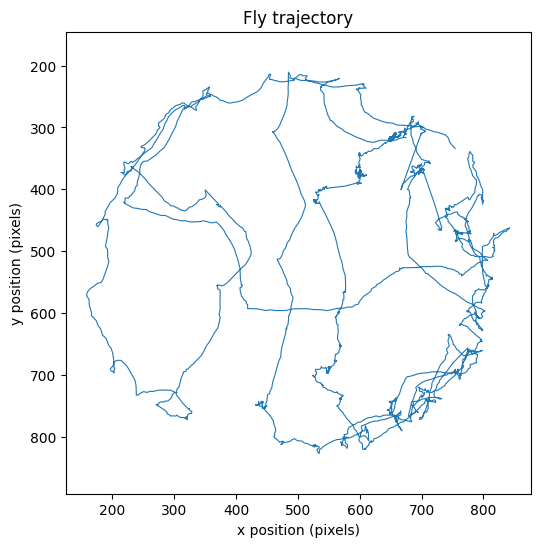

In [136]:
plt.figure(figsize=(6, 6))
plt.plot(
    df["center_x"],
    df["center_y"],
    linewidth=0.8,
)

# Image y-coordinates increase downward, so invert the y-axis
# to make the trajectory match how the video appears.
plt.gca().invert_yaxis()

plt.axis("equal")
plt.xlabel("x position (pixels)")
plt.ylabel("y position (pixels)")
plt.title("Fly trajectory")
plt.show()

# level 1

In [64]:
fps = 15
smooth_window = 5  # frames; at 15 fps, this is ~0.33 s

# ---------- helper functions ----------

def rolling_mean(series, window=5):
    """
    Smooth a time series using a centered rolling average.
    For each frame, it replaces the value with the average of nearby 5 frames.
    """
    return series.rolling(window=window, center=True, min_periods=1).mean()


def angle_from_vector(dx, dy):
    """
    Compute angle from x-y vector using arctan2. The vector is from tail to head.
    Output is in radians, ranging from -pi to +pi.
    """
    return np.arctan2(dy, dx)


def angular_velocity_from_angle(angle_rad, fps):
    """
    Compute angular velocity from an angle time series. The input is the whole body angle column.

    np.unwrap prevents fake jumps at the -180/180 degree boundary. It modifies the body angle for each frame before calculate how many deg is turned.
    Example: 179 deg -> -179 deg should be treated as a 2 deg change, not a -358 deg change.
    """
    angle_unwrapped = np.unwrap(angle_rad)
    angular_velocity_rad_s = np.gradient(angle_unwrapped) * fps # converts from deg/frame to deg/sec
    return np.degrees(angular_velocity_rad_s)

def wrap_angle_deg(angle_deg):
    """
    Wrap angle into the range -180 to +180 degrees.
    This is only for visualization/comparison, not for angular velocity calculation.
    """
    return ((angle_deg + 180) % 360) - 180

# ---------- center position ----------
# body center is the center bewteen the head and the tail.
df["center_x"] = (df["head_x"] + df["tail_x"]) / 2
df["center_y"] = (df["head_y"] + df["tail_y"]) / 2

# ---------- movement direction and speed ----------
# calculate how much the center moved since the previous frame in x and y direction.
dx_move = df["center_x"].diff()
dy_move = df["center_y"].diff()

# calculate the direction the fly is moving.
df["movement_angle_rad"] = np.arctan2(dy_move, dx_move)
df["movement_angle_deg"] = np.degrees(df["movement_angle_rad"])

# calculate distance moved per frame using the x and y displacement of the body center.
df["speed_px_frame"] = np.sqrt(dx_move**2 + dy_move**2)
df["speed_px_s"] = df["speed_px_frame"] * fps

# ---------- body length ----------
# as a check to see whether the tracking is stable, because the body length is supposed to be similar across frames.
df["body_length_px"] = np.sqrt(
    (df["head_x"] - df["tail_x"])**2 +
    (df["head_y"] - df["tail_y"])**2
)

# ---------- Version 1: raw body angle ----------

dx_body_raw = df["head_x"] - df["tail_x"]
dy_body_raw = df["head_y"] - df["tail_y"]

df["body_angle_raw_rad"] = angle_from_vector(dx_body_raw, dy_body_raw)
df["body_angle_raw_deg"] = np.degrees(df["body_angle_raw_rad"])
df["angular_velocity_raw_deg_s"] = angular_velocity_from_angle(
    df["body_angle_raw_rad"], fps
)

# ---------- Version 2: smooth coordinates first, then compute angle ----------
# ask: After removing small coordinate jitter, what direction is the fly body pointing?
# This is better than version 3, because it deals with head/tail swap (bad tracking).
# smooth with 5 frames.
for col in ["head_x", "head_y", "tail_x", "tail_y"]:
    df[f"{col}_smooth"] = rolling_mean(df[col], smooth_window)

dx_body_coord_smooth = df["head_x_smooth"] - df["tail_x_smooth"]
dy_body_coord_smooth = df["head_y_smooth"] - df["tail_y_smooth"]

df["body_angle_coord_smooth_rad"] = angle_from_vector(
    dx_body_coord_smooth, dy_body_coord_smooth
)
df["body_angle_coord_smooth_deg"] = np.degrees(df["body_angle_coord_smooth_rad"])
df["angular_velocity_coord_smooth_deg_s"] = angular_velocity_from_angle(
    df["body_angle_coord_smooth_rad"], fps
)

# ---------- Version 3: compute raw angle first, unwrap it, then smooth angle ----------
# This can work well, but if head/tail gets swapped for one frame, the angle smoothing may smear that error into nearby frames.
body_angle_raw_unwrapped = np.unwrap(df["body_angle_raw_rad"])
body_angle_raw_unwrapped_smooth = rolling_mean(
    pd.Series(body_angle_raw_unwrapped), smooth_window
)

df["body_angle_angle_smooth_rad"] = body_angle_raw_unwrapped_smooth
df["body_angle_angle_smooth_deg"] = np.degrees(body_angle_raw_unwrapped_smooth)
df["angular_velocity_angle_smooth_deg_s"] = np.gradient(
    df["body_angle_angle_smooth_deg"]
) * fps




# Wrapped version of the smoothed-angle method
df["body_angle_angle_smooth_wrapped_deg"] = wrap_angle_deg(
    df["body_angle_angle_smooth_deg"]
)

# ---------- quantify V2 vs V3 angle difference ----------

def circular_angle_diff_deg(angle1_deg, angle2_deg):
    """
    Compute the smallest signed difference between two angles in degrees.
    Output is in range -180 to +180.
    """
    return ((angle1_deg - angle2_deg + 180) % 360) - 180


df["v2_v3_angle_diff_deg"] = circular_angle_diff_deg(
    df["body_angle_coord_smooth_deg"],
    df["body_angle_angle_smooth_wrapped_deg"]
)

df["v2_v3_abs_angle_diff_deg"] = np.abs(df["v2_v3_angle_diff_deg"])

print(df["v2_v3_abs_angle_diff_deg"].describe())

print("Frames with V2/V3 difference > 5 deg:",
      (df["v2_v3_abs_angle_diff_deg"] > 5).sum())

print("Frames with V2/V3 difference > 10 deg:",
      (df["v2_v3_abs_angle_diff_deg"] > 10).sum())

print("Frames with V2/V3 difference > 20 deg:",
      (df["v2_v3_abs_angle_diff_deg"] > 20).sum())


df.head()

count    8.994000e+03
mean     4.851920e+00
std      1.720849e+01
min      3.271310e-09
25%      7.361927e-02
50%      2.699171e-01
75%      6.790926e-01
max      1.798087e+02
Name: v2_v3_abs_angle_diff_deg, dtype: float64
Frames with V2/V3 difference > 5 deg: 1220
Frames with V2/V3 difference > 10 deg: 1013
Frames with V2/V3 difference > 20 deg: 696


,frame_idx,instance_score,tracking_score,head_x,head_y,head_score,tail_x,tail_y,tail_score,center_x,...,tail_y_smooth,body_angle_coord_smooth_rad,body_angle_coord_smooth_deg,angular_velocity_coord_smooth_deg_s,body_angle_angle_smooth_rad,body_angle_angle_smooth_deg,angular_velocity_angle_smooth_deg_s,body_angle_angle_smooth_wrapped_deg,v2_v3_angle_diff_deg,v2_v3_abs_angle_diff_deg
0,0,0.916866,1.000000e+00,536.324463,748.722534,1.045626,544.197815,748.365234,0.575494,540.261139,...,745.805074,3.116767,178.577581,-78.622057,3.115069,178.480322,-69.095657,178.480322,0.097259,0.097259
1,1,0.912407,0.000000e+00,540.411621,744.959106,1.051533,551.603516,745.254456,0.622496,546.007568,...,744.338455,3.025286,173.336111,-30.936933,3.034673,173.873945,-24.525558,173.873945,-0.537834,0.537834
2,2,0.911502,0.000000e+00,544.565674,744.492004,1.039303,556.043823,743.795532,0.676089,550.304749,...,743.675940,3.044773,174.452657,4.661267,3.057996,175.210248,5.296392,175.210248,-0.757591,0.757591
3,3,0.906334,6.246095e-33,548.683655,744.083008,1.027111,560.104309,739.938599,0.734267,554.393982,...,741.974268,3.036133,173.957613,-37.196857,3.046998,174.580131,-34.083976,174.580131,-0.622518,0.622518
4,4,0.912342,0.000000e+00,555.978394,740.950806,1.046620,563.721985,741.025879,0.550099,559.850189,...,740.260864,2.958212,169.493076,-59.012059,2.978679,170.665718,-51.920425,170.665718,-1.172642,1.172642


In [ ]:
# new version,
# should delete the above cell (of level 1)

fps = 15
smooth_window = 5  # 5 frames at 15 fps = about 0.33 seconds

# Add time measured from the beginning of the video.
df["time_s"] = df["frame_idx"] / fps


# ============================================================
# Helper functions
# ============================================================

def rolling_mean_by_valid_segment(series, window=5):
    """
    Smooth a time series using a centered rolling mean.

    Important behavior:
    - One smoothed value is still produced per video frame.
    - Smoothing occurs only within continuous runs of valid values.
    - Long missing gaps remain NaN.
    - Values on opposite sides of a missing gap are not averaged together.

    With window=5, a frame usually uses itself and two neighboring
    frames on each side.
    """
    series = pd.Series(series, index=series.index, dtype=float)
    result = pd.Series(np.nan, index=series.index, dtype=float)

    valid = series.notna()

    # Give each continuous valid/missing run a separate number.
    run_id = valid.ne(valid.shift()).cumsum()

    for _, segment in series[valid].groupby(run_id[valid]):
        result.loc[segment.index] = (
            segment
            .rolling(
                window=window,
                center=True,
                min_periods=1,
            )
            .mean()
        )

    return result


def angle_from_vector(dx, dy):
    """
    Calculate the direction of a vector from its x and y components.

    For body orientation:
        dx = head_x - tail_x
        dy = head_y - tail_y

    Therefore, the vector points from tail to head.

    Output:
        Angle in radians, between -pi and +pi.
    """
    return np.arctan2(dy, dx)


def angular_velocity_from_angle(angle_rad, fps):
    """
    Calculate angular velocity for an entire angle time series.

    Steps for each continuous valid segment:
    1. Unwrap the angle to prevent false jumps at -pi/+pi.
    2. Estimate angle change at every frame using np.gradient.
    3. Multiply by fps to convert radians/frame to radians/second.
    4. Convert radians/second to degrees/second.

    Missing gaps remain NaN and do not affect later valid segments.
    """
    angle_rad = pd.Series(angle_rad, index=angle_rad.index, dtype=float)
    result = pd.Series(np.nan, index=angle_rad.index, dtype=float)

    valid = angle_rad.notna()
    run_id = valid.ne(valid.shift()).cumsum()

    for _, segment in angle_rad[valid].groupby(run_id[valid]):
        values = segment.to_numpy(dtype=float)

        # A derivative cannot be estimated meaningfully from one value.
        if len(values) == 1:
            result.loc[segment.index] = np.nan
            continue

        unwrapped = np.unwrap(values)

        angular_velocity_rad_s = np.gradient(unwrapped) * fps

        result.loc[segment.index] = np.degrees(
            angular_velocity_rad_s
        )

    return result


def unwrap_angle_by_valid_segment(angle_rad):
    """
    Unwrap an angle separately within each continuous valid segment.

    This prevents a long missing gap from contaminating the remainder
    of the recording.
    """
    angle_rad = pd.Series(angle_rad, index=angle_rad.index, dtype=float)
    result = pd.Series(np.nan, index=angle_rad.index, dtype=float)

    valid = angle_rad.notna()
    run_id = valid.ne(valid.shift()).cumsum()

    for _, segment in angle_rad[valid].groupby(run_id[valid]):
        result.loc[segment.index] = np.unwrap(
            segment.to_numpy(dtype=float)
        )

    return result


def wrap_angle_deg(angle_deg):
    """
    Express an angle within the range -180 to +180 degrees.

    This is useful for displaying orientation. The unwrapped angle
    should still be used when calculating angular velocity.
    """
    return ((angle_deg + 180) % 360) - 180


def circular_angle_diff_deg(angle1_deg, angle2_deg):
    """
    Calculate the smallest signed difference between two angles.

    Output is between -180 and +180 degrees.

    Example:
        179 degrees versus -179 degrees gives -2 degrees,
        rather than 358 degrees.
    """
    return ((angle1_deg - angle2_deg + 180) % 360) - 180


# ============================================================
# Center position
# ============================================================

# Estimate the body center as the midpoint between head and tail.
df["center_x"] = (df["head_x"] + df["tail_x"]) / 2
df["center_y"] = (df["head_y"] + df["tail_y"]) / 2


# ============================================================
# Movement direction and translational speed
# ============================================================

# Center displacement from the previous frame.
dx_move = df["center_x"].diff()
dy_move = df["center_y"].diff()

# A displacement should not be calculated across a missing frame.
valid_movement_pair = (
    df["center_x"].notna()
    & df["center_y"].notna()
    & df["center_x"].shift(1).notna()
    & df["center_y"].shift(1).notna()
)

dx_move = dx_move.where(valid_movement_pair)
dy_move = dy_move.where(valid_movement_pair)

# Direction in which the body center moved from the preceding frame.
df["movement_angle_rad"] = np.arctan2(dx_move * 0 + dy_move, dx_move)
df["movement_angle_deg"] = np.degrees(
    df["movement_angle_rad"]
)

# Distance traveled between consecutive frames.
df["speed_px_frame"] = np.sqrt(
    dx_move**2 + dy_move**2
)

# Convert pixels/frame into pixels/second.
df["speed_px_s"] = df["speed_px_frame"] * fps


# ============================================================
# Body length
# ============================================================

# Distance between head and tail.
# This is useful for tracking-quality assessment.
df["body_length_px"] = np.sqrt(
    (df["head_x"] - df["tail_x"])**2
    + (df["head_y"] - df["tail_y"])**2
)


# ============================================================
# Version 1: raw coordinates -> raw body angle
# ============================================================

dx_body_raw = df["head_x"] - df["tail_x"]
dy_body_raw = df["head_y"] - df["tail_y"]

df["body_angle_raw_rad"] = angle_from_vector(
    dx_body_raw,
    dy_body_raw,
)

df["body_angle_raw_deg"] = np.degrees(
    df["body_angle_raw_rad"]
)

df["angular_velocity_raw_deg_s"] = (
    angular_velocity_from_angle(
        df["body_angle_raw_rad"],
        fps,
    )
)


# ============================================================
# Version 2: smooth coordinates first -> calculate body angle
# ============================================================

# Smooth each tracked coordinate independently.
# This reduces small frame-to-frame coordinate jitter.
#
# It may lessen the impact of a one-frame tracking error, but it does
# not guarantee correction of a genuine head-tail swap.
for col in ["head_x", "head_y", "tail_x", "tail_y"]:
    df[f"{col}_smooth"] = rolling_mean_by_valid_segment(
        df[col],
        window=smooth_window,
    )

dx_body_coord_smooth = (
    df["head_x_smooth"] - df["tail_x_smooth"]
)

dy_body_coord_smooth = (
    df["head_y_smooth"] - df["tail_y_smooth"]
)

df["body_angle_coord_smooth_rad"] = angle_from_vector(
    dx_body_coord_smooth,
    dy_body_coord_smooth,
)

df["body_angle_coord_smooth_deg"] = np.degrees(
    df["body_angle_coord_smooth_rad"]
)

df["angular_velocity_coord_smooth_deg_s"] = (
    angular_velocity_from_angle(
        df["body_angle_coord_smooth_rad"],
        fps,
    )
)


# ============================================================
# Version 3: calculate raw angle -> unwrap -> smooth angle
# ============================================================

body_angle_raw_unwrapped = unwrap_angle_by_valid_segment(
    df["body_angle_raw_rad"]
)

body_angle_raw_unwrapped_smooth = (
    rolling_mean_by_valid_segment(
        body_angle_raw_unwrapped,
        window=smooth_window,
    )
)

df["body_angle_angle_smooth_rad"] = (
    body_angle_raw_unwrapped_smooth
)

df["body_angle_angle_smooth_deg"] = np.degrees(
    df["body_angle_angle_smooth_rad"]
)

df["angular_velocity_angle_smooth_deg_s"] = (
    angular_velocity_from_angle(
        df["body_angle_angle_smooth_rad"],
        fps,
    )
)

# Wrapped version is easier to compare visually with Versions 1 and 2.
df["body_angle_angle_smooth_wrapped_deg"] = (
    wrap_angle_deg(
        df["body_angle_angle_smooth_deg"]
    )
)


# ============================================================
# Quantify the difference between Versions 2 and 3
# ============================================================

df["v2_v3_angle_diff_deg"] = circular_angle_diff_deg(
    df["body_angle_coord_smooth_deg"],
    df["body_angle_angle_smooth_wrapped_deg"],
)

df["v2_v3_abs_angle_diff_deg"] = np.abs(
    df["v2_v3_angle_diff_deg"]
)

print("Version 2 versus Version 3 absolute angle difference:")
print(df["v2_v3_abs_angle_diff_deg"].describe())

print(
    "\nFrames with V2/V3 difference > 5 degrees:",
    (df["v2_v3_abs_angle_diff_deg"] > 5).sum(),
)

print(
    "Frames with V2/V3 difference > 10 degrees:",
    (df["v2_v3_abs_angle_diff_deg"] > 10).sum(),
)

print(
    "Frames with V2/V3 difference > 20 degrees:",
    (df["v2_v3_abs_angle_diff_deg"] > 20).sum(),
)

df.head()

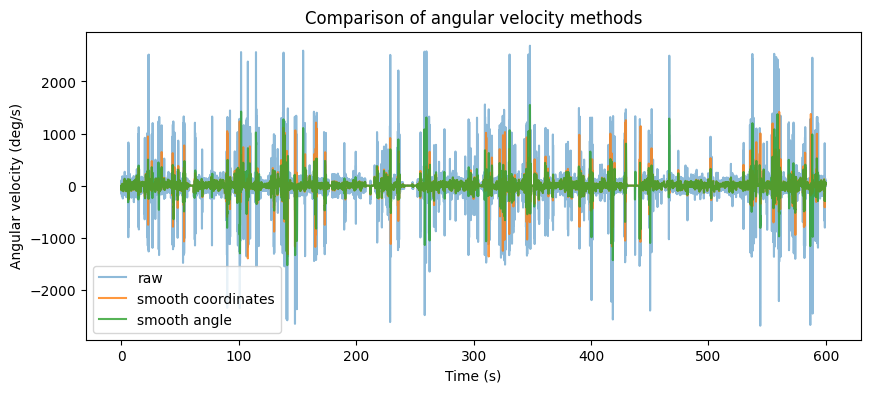

In [51]:
plt.figure(figsize=(10, 4))
plt.plot(df["frame_idx"] / fps, df["angular_velocity_raw_deg_s"], label="raw", alpha=0.5)
plt.plot(df["frame_idx"] / fps, df["angular_velocity_coord_smooth_deg_s"], label="smooth coordinates", alpha=0.8)
plt.plot(df["frame_idx"] / fps, df["angular_velocity_angle_smooth_deg_s"], label="smooth angle", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (deg/s)")
plt.title("Comparison of angular velocity methods")
plt.legend()
plt.show()

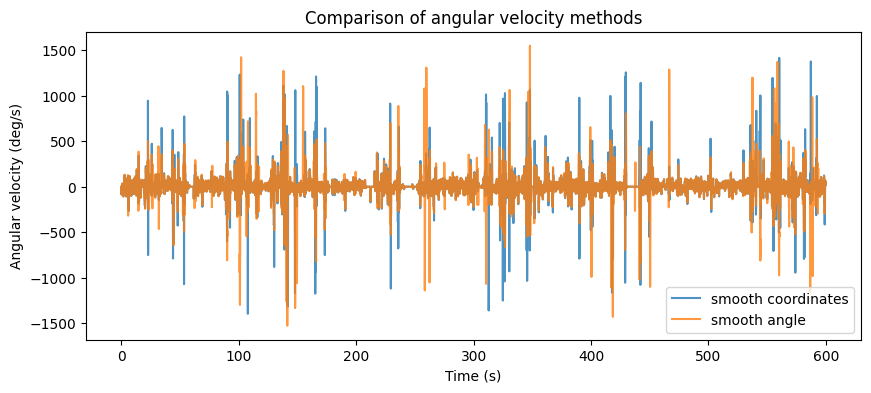

In [56]:
plt.figure(figsize=(10, 4))
plt.plot(df["frame_idx"] / fps, df["angular_velocity_coord_smooth_deg_s"], label="smooth coordinates", alpha=0.8)
plt.plot(df["frame_idx"] / fps, df["angular_velocity_angle_smooth_deg_s"], label="smooth angle", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (deg/s)")
plt.title("Comparison of angular velocity methods")
plt.legend()
plt.show()

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

peak_threshold = 540      # deg/s
min_peak_distance = 5     # frames; prevents one broad peak from being counted many times
match_window = 5          # frames; peaks within this many frames are considered the same event

v2_col = "angular_velocity_coord_smooth_deg_s"
v3_col = "angular_velocity_angle_smooth_deg_s"


def detect_turn_peaks(df, col, threshold=540, min_distance=5):
    """
    Detect turning-event peaks from an angular velocity trace.

    A peak is defined as:
    1. local maximum in absolute angular velocity,
    2. absolute angular velocity >= threshold,
    3. separated from the previous accepted peak by at least min_distance frames.

    Sign tells turn direction:
    positive = one direction, negative = the opposite direction.
    """
    y = df[col].to_numpy()
    abs_y = np.abs(y)

    candidate_idxs = []

    for i in range(1, len(y) - 1):
        if abs_y[i] >= threshold and abs_y[i] >= abs_y[i - 1] and abs_y[i] >= abs_y[i + 1]:
            candidate_idxs.append(i)

    # sort strongest first, then keep peaks far enough apart
    candidate_idxs = sorted(candidate_idxs, key=lambda i: abs_y[i], reverse=True)

    kept = []
    for i in candidate_idxs:
        if all(abs(i - j) >= min_distance for j in kept):
            kept.append(i)

    kept = sorted(kept)

    peaks = pd.DataFrame({
        "idx": kept,
        "frame_idx": df.loc[kept, "frame_idx"].to_numpy(),
        "time_s": df.loc[kept, "frame_idx"].to_numpy() / fps,
        "value": y[kept],
        "abs_value": abs_y[kept],
        "sign": np.sign(y[kept]),
        "method": col,
    })

    return peaks


peaks_v2 = detect_turn_peaks(df, v2_col, peak_threshold, min_peak_distance)
peaks_v3 = detect_turn_peaks(df, v3_col, peak_threshold, min_peak_distance)

print("Version 2 peaks:", len(peaks_v2))
print("Version 3 peaks:", len(peaks_v3))

Version 2 peaks: 69
Version 3 peaks: 55


In [58]:
def match_peaks(peaks_a, peaks_b, match_window=5):
    """
    Match peaks between two methods.

    For each peak in A, find the nearest peak in B within match_window frames.
    Each B peak can only be matched once.
    """
    matches = []
    used_b = set()

    for _, a in peaks_a.iterrows():
        available_b = peaks_b[~peaks_b.index.isin(used_b)].copy()
        if len(available_b) == 0:
            matches.append({
                "v2_idx": a["idx"],
                "v2_time_s": a["time_s"],
                "v2_value": a["value"],
                "v2_abs": a["abs_value"],
                "v3_idx": np.nan,
                "v3_time_s": np.nan,
                "v3_value": np.nan,
                "v3_abs": np.nan,
                "frame_diff": np.nan,
                "same_sign": np.nan,
                "winner": "v2_only",
            })
            continue

        available_b["frame_diff_abs"] = np.abs(available_b["idx"] - a["idx"])
        best_b_idx = available_b["frame_diff_abs"].idxmin()
        b = available_b.loc[best_b_idx]

        if b["frame_diff_abs"] <= match_window:
            used_b.add(best_b_idx)

            same_sign = np.sign(a["value"]) == np.sign(b["value"])

            if a["abs_value"] > b["abs_value"]:
                winner = "v2_larger"
            elif a["abs_value"] < b["abs_value"]:
                winner = "v3_larger"
            else:
                winner = "equal"

            matches.append({
                "v2_idx": a["idx"],
                "v2_time_s": a["time_s"],
                "v2_value": a["value"],
                "v2_abs": a["abs_value"],
                "v3_idx": b["idx"],
                "v3_time_s": b["time_s"],
                "v3_value": b["value"],
                "v3_abs": b["abs_value"],
                "frame_diff": b["idx"] - a["idx"],
                "same_sign": same_sign,
                "winner": winner,
            })
        else:
            matches.append({
                "v2_idx": a["idx"],
                "v2_time_s": a["time_s"],
                "v2_value": a["value"],
                "v2_abs": a["abs_value"],
                "v3_idx": np.nan,
                "v3_time_s": np.nan,
                "v3_value": np.nan,
                "v3_abs": np.nan,
                "frame_diff": np.nan,
                "same_sign": np.nan,
                "winner": "v2_only",
            })

    # add V3 peaks that were not matched
    for b_idx, b in peaks_b.iterrows():
        if b_idx not in used_b:
            matches.append({
                "v2_idx": np.nan,
                "v2_time_s": np.nan,
                "v2_value": np.nan,
                "v2_abs": np.nan,
                "v3_idx": b["idx"],
                "v3_time_s": b["time_s"],
                "v3_value": b["value"],
                "v3_abs": b["abs_value"],
                "frame_diff": np.nan,
                "same_sign": np.nan,
                "winner": "v3_only",
            })

    return pd.DataFrame(matches)


peak_comparison = match_peaks(peaks_v2, peaks_v3, match_window)

peak_comparison.head()

,v2_idx,v2_time_s,v2_value,v2_abs,v3_idx,v3_time_s,v3_value,v3_abs,frame_diff,same_sign,winner
0,341.0,22.733333,943.942370,943.942370,NaN,NaN,NaN,NaN,NaN,NaN,v2_only
1,516.0,34.400000,645.298009,645.298009,NaN,NaN,NaN,NaN,NaN,NaN,v2_only
2,661.0,44.066667,-788.751957,788.751957,NaN,NaN,NaN,NaN,NaN,NaN,v2_only
3,670.0,44.666667,-618.147823,618.147823,668.0,44.533333,-644.645879,644.645879,-2.0,True,v3_larger
4,802.0,53.466667,-1070.453751,1070.453751,NaN,NaN,NaN,NaN,NaN,NaN,v2_only


In [59]:
print(peak_comparison["winner"].value_counts(dropna=False))

shared = peak_comparison[peak_comparison["winner"].isin(["v2_larger", "v3_larger", "equal"])]

print("\nShared peaks:", len(shared))
print("Same sign among shared peaks:")
print(shared["same_sign"].value_counts(dropna=False))

print("\nFor shared peaks only:")
print(shared[["v2_abs", "v3_abs", "frame_diff"]].describe())

winner
v2_only      34
v3_only      20
v2_larger    18
v3_larger    17
Name: count, dtype: int64

Shared peaks: 35
Same sign among shared peaks:
same_sign
False    18
True     17
Name: count, dtype: int64

For shared peaks only:
            v2_abs       v3_abs  frame_diff
count    35.000000    35.000000   35.000000
mean    991.728324   946.245122    0.171429
std     264.807452   308.508888    2.189355
min     540.124781   548.397900   -5.000000
25%     735.001720   693.863162   -1.000000
50%    1034.664009   877.229704    0.000000
75%    1184.750701  1184.114635    1.500000
max    1414.851624  1548.005915    5.000000


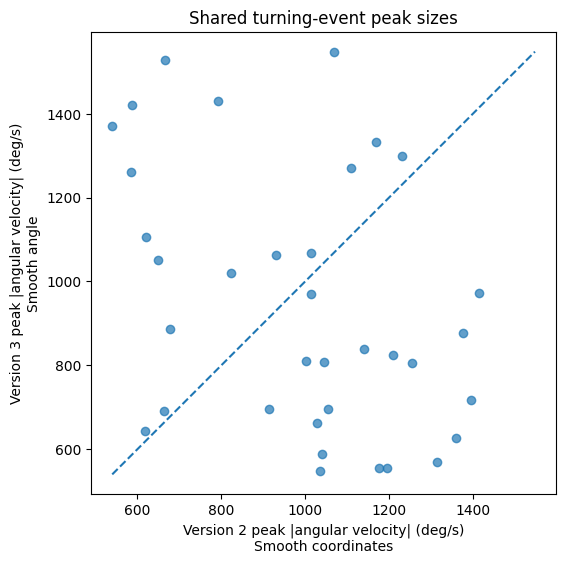

In [60]:
plt.figure(figsize=(6, 6))
plt.scatter(shared["v2_abs"], shared["v3_abs"], alpha=0.7)

max_val = max(shared["v2_abs"].max(), shared["v3_abs"].max())
plt.plot([peak_threshold, max_val], [peak_threshold, max_val], linestyle="--")

plt.xlabel("Version 2 peak |angular velocity| (deg/s)\nSmooth coordinates")
plt.ylabel("Version 3 peak |angular velocity| (deg/s)\nSmooth angle")
plt.title("Shared turning-event peak sizes")
plt.axis("equal")
plt.show()

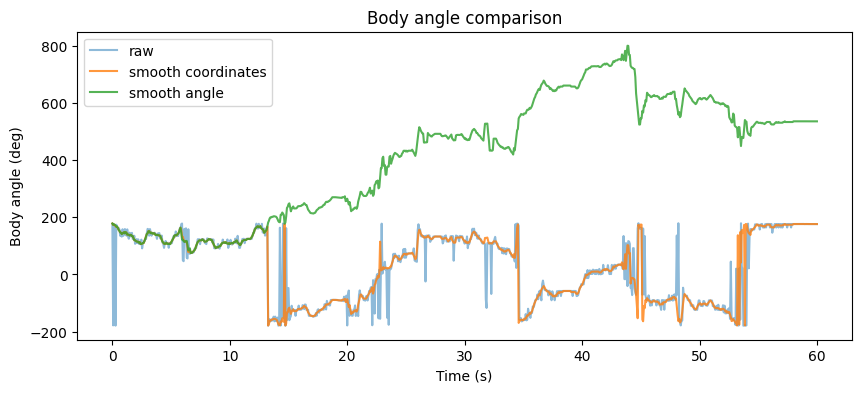

In [52]:
start_s = 0
end_s = 60

mask = (df["frame_idx"] / fps >= start_s) & (df["frame_idx"] / fps <= end_s)

plt.figure(figsize=(10, 4))
plt.plot(df.loc[mask, "frame_idx"] / fps, df.loc[mask, "body_angle_raw_deg"], label="raw", alpha=0.5)
plt.plot(df.loc[mask, "frame_idx"] / fps, df.loc[mask, "body_angle_coord_smooth_deg"], label="smooth coordinates", alpha=0.8)
plt.plot(df.loc[mask, "frame_idx"] / fps, df.loc[mask, "body_angle_angle_smooth_deg"], label="smooth angle", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Body angle (deg)")
plt.title("Body angle comparison")
plt.legend()
plt.show()

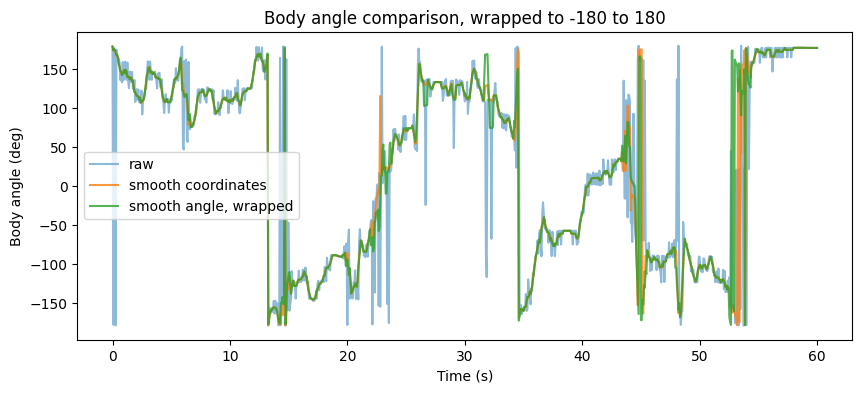

In [62]:
start_s = 0
end_s = 60

mask = (df["frame_idx"] / fps >= start_s) & (df["frame_idx"] / fps <= end_s)

plt.figure(figsize=(10, 4))
plt.plot(df.loc[mask, "frame_idx"] / fps, df.loc[mask, "body_angle_raw_deg"], label="raw", alpha=0.5)
plt.plot(df.loc[mask, "frame_idx"] / fps, df.loc[mask, "body_angle_coord_smooth_deg"], label="smooth coordinates", alpha=0.8)
plt.plot(df.loc[mask, "frame_idx"] / fps, df.loc[mask, "body_angle_angle_smooth_wrapped_deg"], label="smooth angle, wrapped", alpha=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Body angle (deg)")
plt.title("Body angle comparison, wrapped to -180 to 180")
plt.legend()
plt.show()

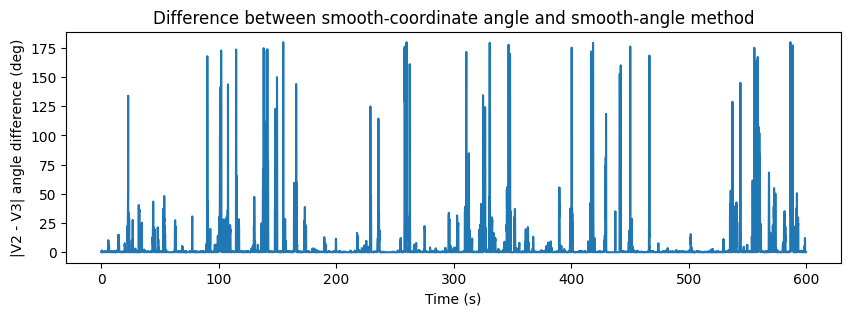

In [65]:
plt.figure(figsize=(10, 3))
plt.plot(df["frame_idx"] / fps, df["v2_v3_abs_angle_diff_deg"])
plt.xlabel("Time (s)")
plt.ylabel("|V2 - V3| angle difference (deg)")
plt.title("Difference between smooth-coordinate angle and smooth-angle method")
plt.show()

In [66]:
# ---------- QC: confidence, body length, sudden flips ----------

# body length summary
body_len_median = df["body_length_px"].median()
body_len_mad = np.median(np.abs(df["body_length_px"] - body_len_median))

print("Median body length:", body_len_median)
print("Body length MAD:", body_len_mad)

# robust body length outlier threshold
df["qc_body_length_outlier"] = (
    np.abs(df["body_length_px"] - body_len_median) > 4 * body_len_mad
)

# low confidence threshold
score_threshold = 0.5

df["qc_low_head_score"] = df["head_score"] < score_threshold
df["qc_low_tail_score"] = df["tail_score"] < score_threshold
df["qc_low_instance_score"] = df["instance_score"] < score_threshold

# sudden angle jump using primary angle method: V2 smooth-coordinate body angle
df["body_angle_primary_deg"] = df["body_angle_coord_smooth_deg"]

df["angle_jump_deg"] = np.abs(
    circular_angle_diff_deg(
        df["body_angle_primary_deg"],
        df["body_angle_primary_deg"].shift(1)
    )
)

# sudden 180-ish jumps may indicate head/tail swaps or real sharp reversals
df["qc_large_angle_jump"] = df["angle_jump_deg"] > 120

# low movement + large angle jump is suspicious for head/tail swap
df["qc_possible_head_tail_swap"] = (
    df["qc_large_angle_jump"] &
    (df["speed_px_s"] < 20)
)

# combined QC flag
df["qc_any_issue"] = (
    df["qc_body_length_outlier"] |
    df["qc_low_head_score"] |
    df["qc_low_tail_score"] |
    df["qc_low_instance_score"] |
    df["qc_possible_head_tail_swap"]
)

qc_cols = [
    "qc_body_length_outlier",
    "qc_low_head_score",
    "qc_low_tail_score",
    "qc_low_instance_score",
    "qc_large_angle_jump",
    "qc_possible_head_tail_swap",
    "qc_any_issue",
]

df[qc_cols].sum()

Median body length: 12.605931595941378
Body length MAD: 1.4063915098908275


qc_body_length_outlier        116
qc_low_head_score               0
qc_low_tail_score              70
qc_low_instance_score          48
qc_large_angle_jump            23
qc_possible_head_tail_swap      1
qc_any_issue                  189
dtype: int64

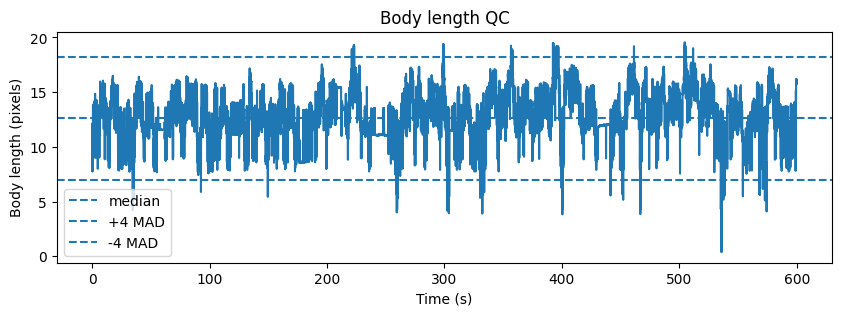

In [67]:
plt.figure(figsize=(10, 3))
plt.plot(df["frame_idx"] / fps, df["body_length_px"])
plt.axhline(body_len_median, linestyle="--", label="median")
plt.axhline(body_len_median + 4 * body_len_mad, linestyle="--", label="+4 MAD")
plt.axhline(body_len_median - 4 * body_len_mad, linestyle="--", label="-4 MAD")
plt.xlabel("Time (s)")
plt.ylabel("Body length (pixels)")
plt.title("Body length QC")
plt.legend()
plt.show()

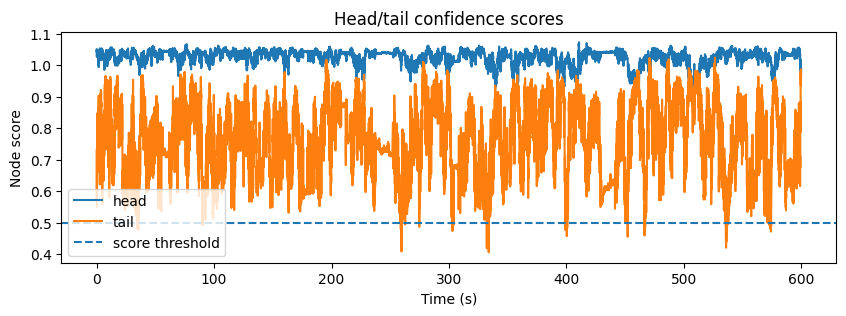

In [68]:
plt.figure(figsize=(10, 3))
plt.plot(df["frame_idx"] / fps, df["head_score"], label="head")
plt.plot(df["frame_idx"] / fps, df["tail_score"], label="tail")
plt.axhline(score_threshold, linestyle="--", label="score threshold")
plt.xlabel("Time (s)")
plt.ylabel("Node score")
plt.title("Head/tail confidence scores")
plt.legend()
plt.show()

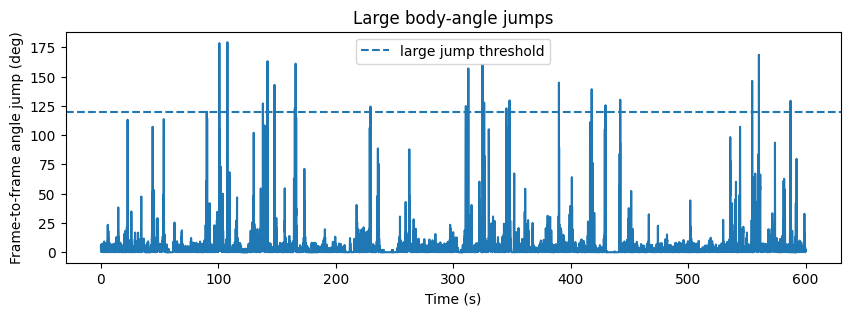

In [69]:
plt.figure(figsize=(10, 3))
plt.plot(df["frame_idx"] / fps, df["angle_jump_deg"])
plt.axhline(120, linestyle="--", label="large jump threshold")
plt.xlabel("Time (s)")
plt.ylabel("Frame-to-frame angle jump (deg)")
plt.title("Large body-angle jumps")
plt.legend()
plt.show()

In [70]:
suspicious = df.loc[df["qc_any_issue"], [
    "frame_idx",
    "center_x", "center_y",
    "speed_px_s",
    "body_length_px",
    "head_score", "tail_score", "instance_score",
    "body_angle_primary_deg",
    "angle_jump_deg",
    "qc_body_length_outlier",
    "qc_low_head_score",
    "qc_low_tail_score",
    "qc_low_instance_score",
    "qc_possible_head_tail_swap",
]]

suspicious.head(20)

,frame_idx,center_x,center_y,speed_px_s,body_length_px,head_score,tail_score,instance_score,body_angle_primary_deg,angle_jump_deg,qc_body_length_outlier,qc_low_head_score,qc_low_tail_score,qc_low_instance_score,qc_possible_head_tail_swap
519,519,622.310394,395.811569,95.172793,4.215177,1.024432,0.482588,0.711213,-169.852702,14.896457,True,False,True,False,False
533,533,590.554230,381.770966,55.858763,5.245486,1.017375,0.477793,0.736914,-135.209774,5.843026,True,False,True,False,False
1349,1349,600.477356,414.060349,92.301038,8.110475,1.040800,0.494040,0.663622,-83.312355,1.116852,False,False,True,False,False
1356,1356,636.507874,400.581863,65.351540,7.427761,1.037966,0.492965,0.661304,-3.815894,22.187907,False,False,True,False,False
1390,1390,654.539978,390.502716,124.391095,5.885482,1.043556,0.549453,0.635319,-3.663954,18.180227,True,False,False,False,False
2244,2244,538.236816,750.740112,144.236216,5.441526,1.047324,0.549223,0.904688,164.819122,5.177094,True,False,False,False,False
3316,3316,330.355423,380.171188,89.173671,18.939670,0.968128,0.960123,0.916517,8.574154,0.116662,True,False,False,False,False
3317,3317,334.455734,376.836456,79.277505,18.798113,0.979146,0.956737,0.910246,6.115990,2.458164,True,False,False,False,False
3338,3338,370.376541,316.935562,35.998522,18.767365,0.980448,0.925048,0.801660,5.419828,2.760011,True,False,False,False,False
3339,3339,374.562805,316.869568,62.801763,18.771614,0.981671,0.923227,0.841303,0.436166,4.983661,True,False,False,False,False


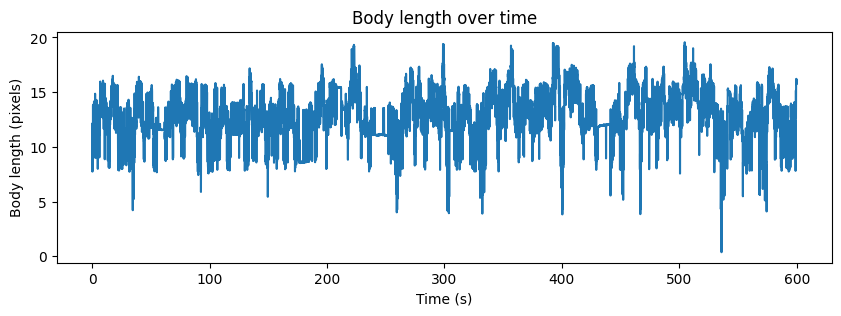

count    8994.000000
mean       12.889455
std         2.275051
min         0.377715
25%        11.601750
50%        12.605932
75%        14.370213
max        19.564778
Name: body_length_px, dtype: float64

In [53]:
plt.figure(figsize=(10, 3))
plt.plot(df["frame_idx"] / fps, df["body_length_px"])
plt.xlabel("Time (s)")
plt.ylabel("Body length (pixels)")
plt.title("Body length over time")
plt.show()

df["body_length_px"].describe()

# level 2

stopped	        speed < 20 AND not turning\
stationary_turn	speed < 20 AND turning\
straight_walk	speed > 40 AND not turning\
walking_turn	speed > 40 AND turning\
slow_transition	everything in between (20–40 px/s)

In [87]:
speed_stop_threshold = 20      # px/s
speed_walk_threshold = 40      # px/s
turn_threshold = 100           # deg/s

# Turning magnitude
df["abs_angular_velocity_deg_s"] = np.abs(
    df["angular_velocity_coord_smooth_deg_s"]
)

# Basic conditions
is_stop = df["speed_px_s"] < speed_stop_threshold
is_walk = df["speed_px_s"] > speed_walk_threshold
is_turn = df["abs_angular_velocity_deg_s"] > turn_threshold

# Final behavioral states
df["behavior_state"] = "slow_transition"

df.loc[is_stop & ~is_turn, "behavior_state"] = "stopped"

df.loc[is_stop & is_turn, "behavior_state"] = "stationary_turn"

df.loc[is_walk & ~is_turn, "behavior_state"] = "straight_walk"

df.loc[is_walk & is_turn, "behavior_state"] = "walking_turn"
state_order = ["stopped", "stationary_turn", "slow_transition", "straight_walk", "walking_turn"]

# Summary
print(df["behavior_state"].value_counts())
print()
print(df["behavior_state"].value_counts(normalize=True))

behavior_state
straight_walk      4541
stopped            2179
slow_transition    1202
walking_turn        907
stationary_turn     165
Name: count, dtype: int64

behavior_state
straight_walk      0.504892
stopped            0.242273
slow_transition    0.133645
walking_turn       0.100845
stationary_turn    0.018346
Name: proportion, dtype: float64


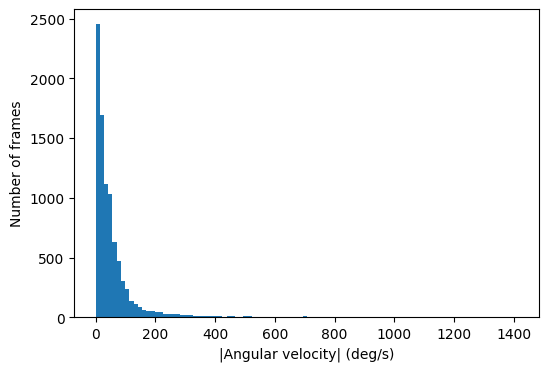

In [79]:
# choosing the turn threshold
plt.figure(figsize=(6,4))
plt.hist(
    np.abs(df["angular_velocity_coord_smooth_deg_s"]),
    bins=100
)
plt.xlabel("|Angular velocity| (deg/s)")
plt.ylabel("Number of frames")
plt.show()

In [80]:
df["abs_angular_velocity_deg_s"].describe()

count    8994.000000
mean       64.719044
std       127.109044
min         0.000282
25%        11.107302
50%        31.912726
75%        66.057845
max      1414.851624
Name: abs_angular_velocity_deg_s, dtype: float64

chatgpt suggestion for turn threshold:
I think we should avoid choosing thresholds based only on the statistics. Instead, we should use the videos.

For example:

1. Pick 20 random frames where the angular velocity is around 100°/s.
2. Watch those frames in the video.
3. Ask: "Would a human observer say this fly is turning?"
4. Repeat for 150°/s, 200°/s, 300°/s.

Then we choose the threshold that best matches what you, as the experimenter, consider a "turn."

This grounds the analysis in the actual behavior rather than an arbitrary percentile. Since you already inspect your videos to judge tracking quality, I think this calibration step will make the behavioral definitions much more meaningful and defensible.

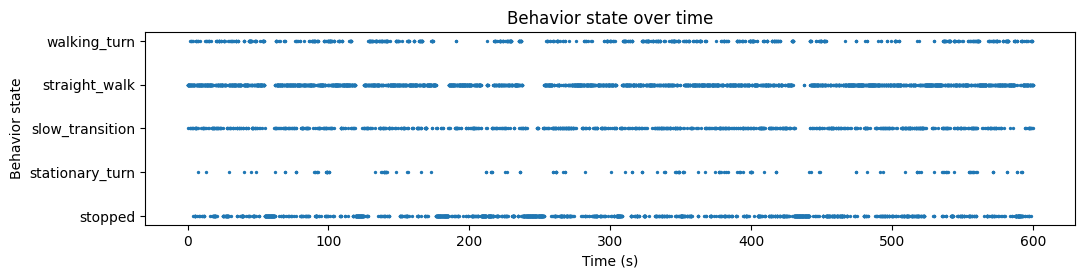

In [88]:
state_to_num = {state: i for i, state in enumerate(state_order)}
df["behavior_state_num"] = df["behavior_state"].map(state_to_num)

plt.figure(figsize=(12, 2.5))
plt.scatter(df["frame_idx"] / fps, df["behavior_state_num"], s=2)
plt.yticks(range(len(state_order)), state_order)
plt.xlabel("Time (s)")
plt.ylabel("Behavior state")
plt.title("Behavior state over time")
plt.show()

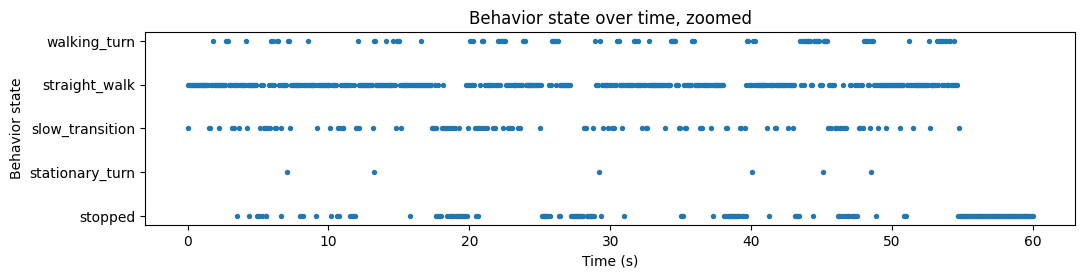

In [91]:
start_s = 0
end_s = 60

mask = (df["frame_idx"] / fps >= start_s) & (df["frame_idx"] / fps <= end_s)

plt.figure(figsize=(12, 2.5))
plt.scatter(
    df.loc[mask, "frame_idx"] / fps,
    df.loc[mask, "behavior_state_num"],
    s=8
)
plt.yticks(range(len(state_order)), state_order)
plt.xlabel("Time (s)")
plt.ylabel("Behavior state")
plt.title("Behavior state over time, zoomed")
plt.show()

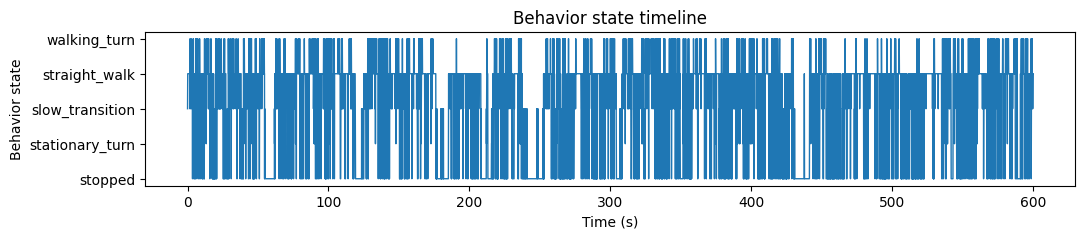

In [92]:
plt.figure(figsize=(12, 2))

plt.plot(
    df["frame_idx"] / fps,
    df["behavior_state_num"],
    linewidth=1
)

plt.yticks(range(len(state_order)), state_order)
plt.xlabel("Time (s)")
plt.ylabel("Behavior state")
plt.title("Behavior state timeline")
plt.show()

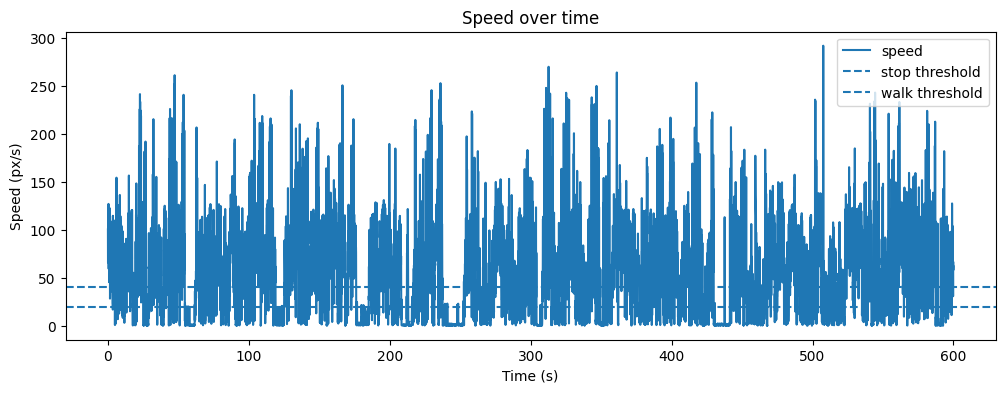

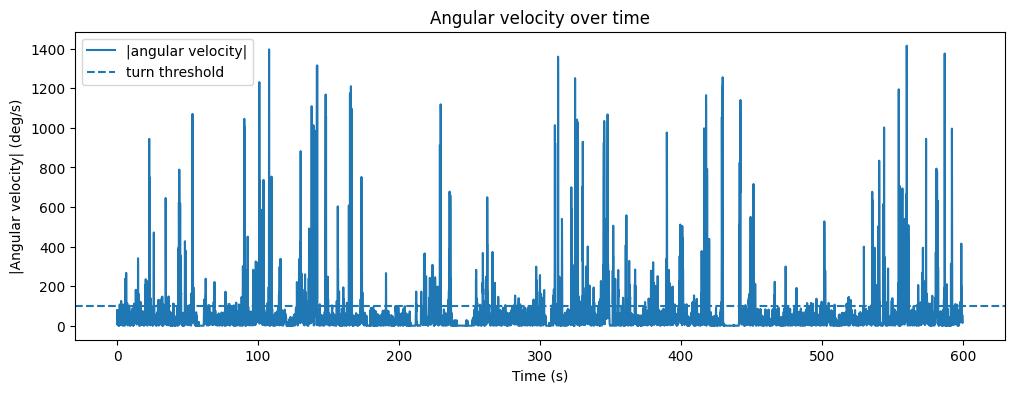

In [94]:
plt.figure(figsize=(12, 4))

plt.plot(df["frame_idx"] / fps, df["speed_px_s"], label="speed")
plt.axhline(speed_stop_threshold, linestyle="--", label="stop threshold")
plt.axhline(speed_walk_threshold, linestyle="--", label="walk threshold")

plt.xlabel("Time (s)")
plt.ylabel("Speed (px/s)")
plt.title("Speed over time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))

plt.plot(df["frame_idx"] / fps, df["abs_angular_velocity_deg_s"], label="|angular velocity|")
plt.axhline(turn_threshold, linestyle="--", label="turn threshold")

plt.xlabel("Time (s)")
plt.ylabel("|Angular velocity| (deg/s)")
plt.title("Angular velocity over time")
plt.legend()
plt.show()

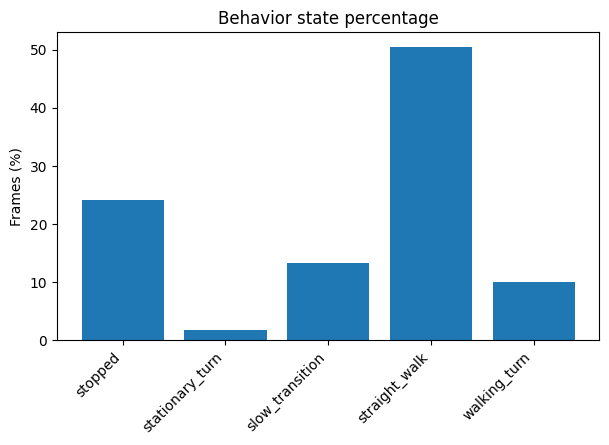

In [89]:
state_frac = df["behavior_state"].value_counts(normalize=True).reindex(state_order).fillna(0) * 100

plt.figure(figsize=(7, 4))
plt.bar(state_frac.index, state_frac.values)
plt.ylabel("Frames (%)")
plt.title("Behavior state percentage")
plt.xticks(rotation=45, ha="right")
plt.show()

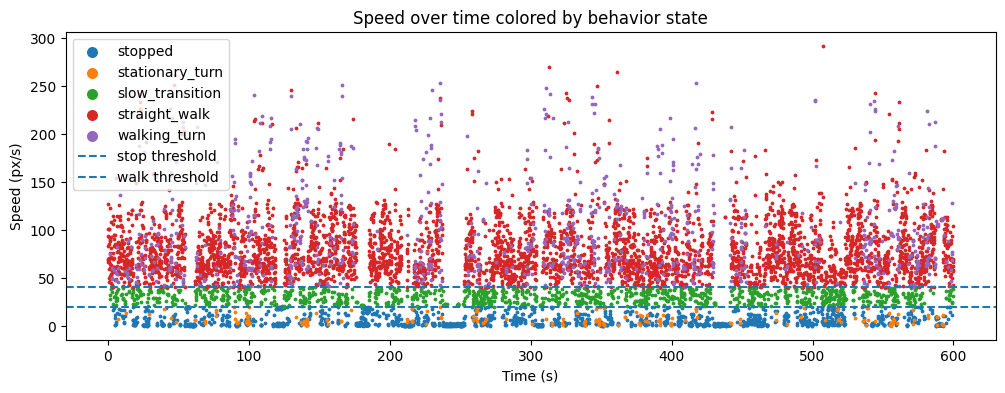

In [90]:
plt.figure(figsize=(12, 4))

for state in state_order:
    mask = df["behavior_state"] == state
    plt.scatter(
        df.loc[mask, "frame_idx"] / fps,
        df.loc[mask, "speed_px_s"],
        s=3,
        label=state
    )

plt.axhline(speed_stop_threshold, linestyle="--", label="stop threshold")
plt.axhline(speed_walk_threshold, linestyle="--", label="walk threshold")

plt.xlabel("Time (s)")
plt.ylabel("Speed (px/s)")
plt.title("Speed over time colored by behavior state")
plt.legend(markerscale=4)
plt.show()

# level 3

In [95]:
def extract_behavior_bouts(
    df,
    *,
    state_col="behavior_state",
    frame_col="frame_idx",
    fps=15,
):
    """
    Convert frame-by-frame behavioral states into a bout table.

    A new bout begins when:
    1. the behavioral state changes, or
    2. the frame numbers are no longer consecutive.

    Each output row describes one continuous behavioral bout.
    """

    work = df.copy()

    # A new bout starts when the state changes.
    state_changed = work[state_col] != work[state_col].shift(1)

    # A new bout also starts if a video frame is missing.
    frame_gap = work[frame_col].diff().fillna(1) != 1

    # Number each consecutive bout.
    work["bout_id"] = (state_changed | frame_gap).cumsum()

    bout_rows = []

    for bout_id, bout_df in work.groupby("bout_id", sort=True):

        start_frame = int(bout_df[frame_col].iloc[0])
        end_frame = int(bout_df[frame_col].iloc[-1])
        n_frames = len(bout_df)

        # A bout containing N frames lasts N / fps seconds.
        duration_s = n_frames / fps

        # Distance is the sum of center displacement within the bout.
        dx = bout_df["center_x"].diff()
        dy = bout_df["center_y"].diff()
        distance_px = np.sqrt(dx**2 + dy**2).sum()

        bout_rows.append({
            "bout_id": int(bout_id),
            "behavior_state": bout_df[state_col].iloc[0],

            "start_frame": start_frame,
            "end_frame": end_frame,
            "start_time_s": start_frame / fps,
            "end_time_s": (end_frame + 1) / fps,

            "n_frames": n_frames,
            "duration_s": duration_s,

            "mean_speed_px_s": bout_df["speed_px_s"].mean(),
            "max_speed_px_s": bout_df["speed_px_s"].max(),

            "mean_abs_angular_velocity_deg_s":
                bout_df["abs_angular_velocity_deg_s"].mean(),

            "max_abs_angular_velocity_deg_s":
                bout_df["abs_angular_velocity_deg_s"].max(),

            "distance_px": distance_px,

            "start_x": bout_df["center_x"].iloc[0],
            "start_y": bout_df["center_y"].iloc[0],
            "end_x": bout_df["center_x"].iloc[-1],
            "end_y": bout_df["center_y"].iloc[-1],
        })

    return pd.DataFrame(bout_rows)


bouts_raw = extract_behavior_bouts(
    df,
    state_col="behavior_state",
    frame_col="frame_idx",
    fps=fps,
)

bouts_raw.head()

,bout_id,behavior_state,start_frame,end_frame,start_time_s,end_time_s,n_frames,duration_s,mean_speed_px_s,max_speed_px_s,mean_abs_angular_velocity_deg_s,max_abs_angular_velocity_deg_s,distance_px,start_x,start_y,end_x,end_y
0,1,slow_transition,0,0,0.000000,0.066667,1,0.066667,NaN,NaN,78.622057,78.622057,0.000000,540.261139,748.543884,540.261139,748.543884
1,2,straight_walk,1,22,0.066667,1.533333,22,1.466667,78.924529,127.089825,34.226498,78.426097,109.060072,546.007568,745.106781,634.409088,688.934906
2,3,slow_transition,23,24,1.533333,1.666667,2,0.133333,30.200342,32.095661,26.204865,36.078958,2.139711,636.201904,688.346191,638.312317,687.993317
3,4,straight_walk,25,26,1.666667,1.800000,2,0.133333,62.601627,76.345095,40.648179,49.452708,3.257211,642.343567,684.886261,644.500885,682.445892
4,5,walking_turn,27,27,1.800000,1.866667,1,0.066667,75.300521,75.300521,107.386160,107.386160,0.000000,647.829315,678.687927,647.829315,678.687927


In [96]:
print("Total raw bouts:", len(bouts_raw))

print(
    bouts_raw["behavior_state"]
    .value_counts()
    .reindex(state_order)
    .fillna(0)
    .astype(int)
)

Total raw bouts: 3234
behavior_state
stopped             660
stationary_turn     135
slow_transition     867
straight_walk      1089
walking_turn        483
Name: count, dtype: int64


In [97]:
# Adjustable minimum bout durations.
# These are provisional and can be changed after inspecting the video.

minimum_duration_s = {
    "stopped": 1.0,
    "stationary_turn": 0.20,
    "slow_transition": 0.0,
    "straight_walk": 0.30,
    "walking_turn": 0.20,
}

In [98]:
bouts_raw["minimum_duration_s"] = (
    bouts_raw["behavior_state"].map(minimum_duration_s)
)

bouts_raw["passes_minimum_duration"] = (
    bouts_raw["duration_s"] >= bouts_raw["minimum_duration_s"]
)

bouts_valid = bouts_raw.loc[
    bouts_raw["passes_minimum_duration"]
].copy()

print("Raw bouts:", len(bouts_raw))
print("Bouts passing minimum duration:", len(bouts_valid))

Raw bouts: 3234
Bouts passing minimum duration: 1273


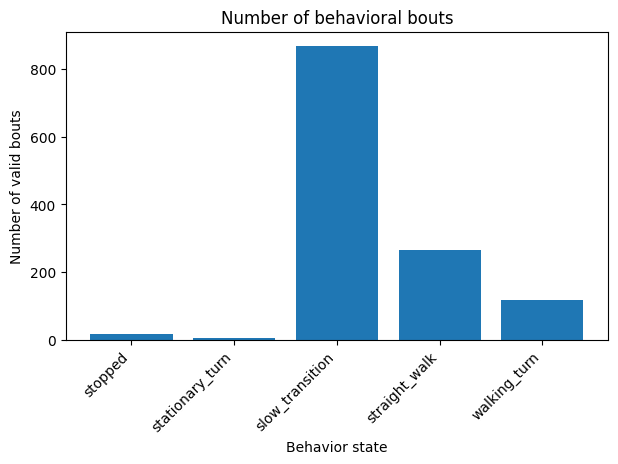

In [99]:
bout_counts = (
    bouts_valid["behavior_state"]
    .value_counts()
    .reindex(state_order)
    .fillna(0)
)

plt.figure(figsize=(7, 4))
plt.bar(bout_counts.index, bout_counts.values)

plt.xlabel("Behavior state")
plt.ylabel("Number of valid bouts")
plt.title("Number of behavioral bouts")
plt.xticks(rotation=45, ha="right")
plt.show()

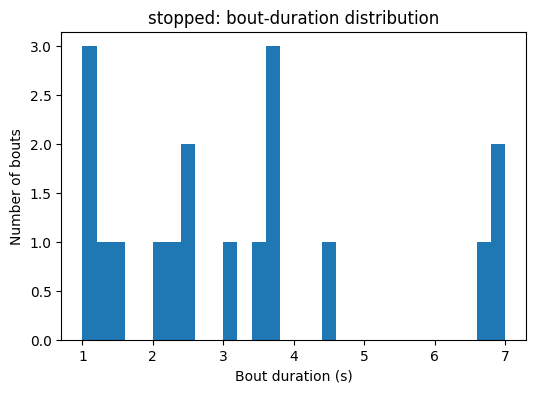

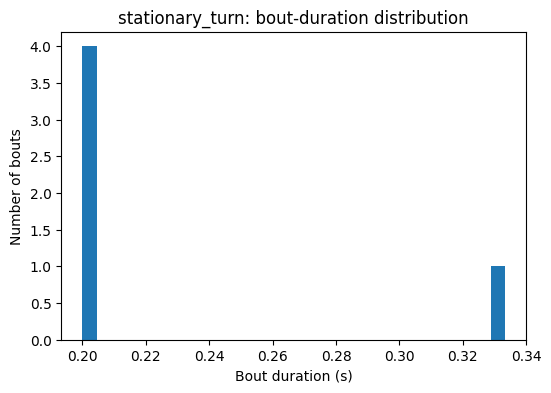

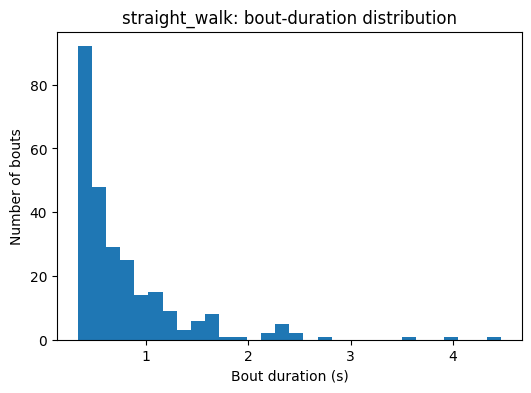

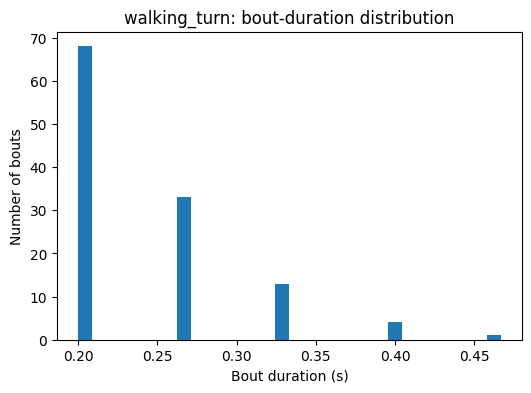

In [100]:
states_to_plot = [
    "stopped",
    "stationary_turn",
    "straight_walk",
    "walking_turn",
]

for state in states_to_plot:
    durations = bouts_valid.loc[
        bouts_valid["behavior_state"] == state,
        "duration_s"
    ]

    plt.figure(figsize=(6, 4))
    plt.hist(durations, bins=30)

    plt.xlabel("Bout duration (s)")
    plt.ylabel("Number of bouts")
    plt.title(f"{state}: bout-duration distribution")
    plt.show()

In [101]:
bout_duration_summary = (
    bouts_valid
    .groupby("behavior_state")["duration_s"]
    .agg(
        n_bouts="count",
        mean_duration_s="mean",
        median_duration_s="median",
        max_duration_s="max",
    )
    .reindex(state_order)
)

bout_duration_summary

,n_bouts,mean_duration_s,median_duration_s,max_duration_s
behavior_state,,,,
stopped,18,3.200000,2.800000,7.000000
stationary_turn,5,0.226667,0.200000,0.333333
slow_transition,867,0.092426,0.066667,0.400000
straight_walk,264,0.794949,0.600000,4.466667
walking_turn,119,0.242017,0.200000,0.466667
